Data Science for Linguists Project (WS 2024)


Native Language Identification (NLI) is a task which consists in detecting the native language of a speaker, given a production in their L2. Transfer learning, in which linguistic features from the L1 make it into the L2 as part of the acquisition process, is a well-documented phenomenon: dissimilarity between the L1 and L2 can introduce biases and errors during production, which then creates a signal that makes it distinguishable from L1 features. Looking at the 2017 shared task on NLI, it looks like a lot of the approaches to the problem relied on different n-gram features with either logistic regression or supervised learning models (such as SVMs).

In the following project, I will compare these traditional approaches to NLI on two different datasets, and attempt to analyze the results given the corpus context. According to [this survey paper](https://aclanthology.org/2024.naacl-long.173.pdf), there can be a number of confounding factors, such as topic (in a language learning setting, a lot can be inferred if the learners write about their own country for instance), but also proficiency level (the more advanced the learner is, the more their language distribution will be similar to that of a native speaker).

I will look at the following features (from language-specific to language agnostic): token n-grams (testing out stopwords + tfidf vectors as well), UPOS n-grams and dependency n-grams, in combination with SVM models, trying out different kernels and model parameters. Before passing the data to the SVMs, I will compute the Mutual Information / Information Gain (taking inspiration from, [a BA thesis which looks at classifying Slavic/ non-Slavic languages within the same corpus I am using for Czech](https://dspace.cuni.cz/bitstream/handle/20.500.11956/73979/BPTX_2015_1_11320_0_378945_0_172519.pdf?sequence=1&isAllowed=y) dataset by first computing the Information gain of different n-gram features )
Finally, I will also try to apply a graph kernel (the Weisfeiler Lehman kernel, which takes node and edge values into account) to the UD-based dependency graphs.

I will try to minimize the potential influence of additional factors by making sure texts across both datasets are of similar length, and have similar sample sizes.
We will look at four languages, chosen due to the difference between their own syntactic structures, but also their consistent presence in both datasets: Chinese, Japanese, French and German

In [ ]:
!pip install gdown -q
import gdown
import os
import zipfile

In [ ]:
import nltk

In [ ]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 19.7 MB/s eta 0:00:00


In [ ]:
!pip install sacremoses
!pip install conllu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 11.0 MB/s eta 0:00:00


In [ ]:
import re
import matplotlib.pyplot as plt

Downloading the BAWE + CzESL data

In [ ]:
ENG_CONLL_ID = "1HvaGv6cWbhTCCg2iKsV3PwVaDjLRLG-M"
ENG_CSV_ID = "1UuUC6UxvhDe9NxaZJWENs7St-6VvU2Fb"
ENG_ASCII_ID = "16ysPxyrI1ds7uqVa_bx2tJXJFwKwCAUz"
CZE_FILE_ID = "1RBCMuaPXF-TPb1pjErxZ8E0irJaL_ZAm"

LOCAL_BASE = "/content/datasets"
ENG_RAW  = f"{LOCAL_BASE}/eng/raw"
ENG_DATA = f"{LOCAL_BASE}/eng/data"
CZE_DIR  = f"{LOCAL_BASE}/cze"

for path in [ENG_RAW, ENG_DATA, CZE_DIR]:
    os.makedirs(path, exist_ok=True)


for i, file_id in enumerate([ENG_CONLL_ID, ENG_CSV_ID, ENG_ASCII_ID], 1):
    print(f"Downloading english zip {i}...")
    gdown.download(id=file_id, output=ENG_RAW + "/", quiet=False, fuzzy=True)

print("Downloading czech file...")
gdown.download(id=CZE_FILE_ID, output=CZE_DIR + "/", quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1HvaGv6cWbhTCCg2iKsV3PwVaDjLRLG-M
From (redirected): https://drive.google.com/uc?id=1HvaGv6cWbhTCCg2iKsV3PwVaDjLRLG-M&confirm=t&uuid=8aafd0d8-3f65-457f-82dc-2b3d1a357bcc
To: /content/datasets/eng/raw/BAWE_conll.zip
100%|██████████| 49.2M/49.2M [00:00<00:00, 88.6MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1UuUC6UxvhDe9NxaZJWENs7St-6VvU2Fb
From (redirected): https://drive.google.com/uc?id=1UuUC6UxvhDe9NxaZJWENs7St-6VvU2Fb&confirm=t&uuid=01e3eb87-451e-4aef-82ce-6a20ec52c21f
To: /content/datasets/eng/raw/BAWE_csv.zip
100%|██████████| 65.1M/65.1M [00:00<00:00, 68.7MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=16ysPxyrI1ds7uqVa_bx2tJXJFwKwCAUz
From (redirected): https://drive.google.com/uc?id=16ysPxyrI1ds7uqVa_bx2tJXJFwKwCAUz&confirm=t&uuid=5e2b4b6b-d1aa-4f69-96c4-80b1ae5ff665
To: /content/datasets/eng/raw/CORPUS_ASCII.zip
100%|██████████| 23.7M/23.7M [00:00<00:00, 80.2MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1RBCMuaPXF-TPb1pjErxZ8E0irJaL_ZAm
From (redirected): https://drive.google.com/uc?id=1RBCMuaPXF-TPb1pjErxZ8E0irJaL_ZAm&confirm=t&uuid=906042e4-f6d9-41de-8c21-839d9c651371
To: /content/datasets/cze/2014-czesl-sgt-en-all-v2.xml
100%|██████████| 143M/143M [00:01<00:00, 133MB/s]


'/content/datasets/cze/2014-czesl-sgt-en-all-v2.xml'

In [ ]:
import os
import zipfile

ENG_RAW  = "/content/datasets/eng/raw"
ENG_DATA = "/content/datasets/eng/data"
os.makedirs(ENG_DATA, exist_ok=True)

for fname in os.listdir(ENG_RAW):
    if fname.endswith(".zip"):
        zip_path = os.path.join(ENG_RAW, fname)
        out_dir = os.path.join(ENG_DATA, fname.replace(".zip", ""))
        os.makedirs(out_dir, exist_ok=True)
        print(f"Unzipping {fname} → {out_dir}")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)

print("\nDone! eng/data contents:")
for f in os.listdir(ENG_DATA):
    print(f"  {f}")

Unzipping CORPUS_ASCII.zip → /content/datasets/eng/data/CORPUS_ASCII
Unzipping BAWE_csv.zip → /content/datasets/eng/data/BAWE_csv
Unzipping BAWE_conll.zip → /content/datasets/eng/data/BAWE_conll

Done! eng/data contents:
  BAWE_csv
  BAWE_conll
  CORPUS_ASCII


In [ ]:
eng_text_folder = "/content/datasets/eng/data/CORPUS_ASCII/CORPUS_ASCII"
eng_csv_folder = "/content/datasets/eng/data/BAWE_csv/BAWE_csv"
eng_conll_folder = "/content/datasets/eng/data/BAWE_conll/BAWE_conll"
cz_file = "/content/datasets/cze/2014-czesl-sgt-en-all-v2.xml"

Data Processing: BAWE dataset.

The British Academic Written English corpus contains around 2500 essays (ranging form 500 to 2500 words long), written by students at different UK universities [and is distributed by the University of Warwick](https://warwick.ac.uk/fac/soc/al/research/collections/bawe/). The topics (areas of study, e.g humanities, engineering) are evenly distributed according to the corpus documentation.
The corpus is available in TEI format, with attributes specifying the native language of the writer. For the purposes of this study, since we are looking at linguistic features, we will be using a tokenized, processed version of this dataset, available on [this page](https://phildurrant.net/parsed-bawe-corpus/). The texts were processed using the Stanza NLP pipeline, applying POS tagging and dependency annotations. We first use the official BAWE corpus to extract the paths to the texts available for each language, before using their IDs to obtain the tagged equivalent.

In [ ]:
import os
import lxml
from collections import defaultdict
from lxml import etree
import pandas as pd
from sklearn.utils import Bunch

from sacremoses import MosesDetokenizer
import conllu
from sklearn.preprocessing import LabelEncoder


Parsing the XML corpus for BAWE to obtain the language distribution

In [ ]:
detok = MosesDetokenizer(lang="en")

def first_language(filepath):
    try:
        tree = etree.parse(filepath)
        root = tree.getroot()
        node = root.find('.//{*}particDesc//{*}p[@n="first language"]')
        return node.text if node is not None else None
    except lxml.etree.XMLSyntaxError:
        print(f"TEI parsing error: {filepath}")
        return None

BAWE_xml = eng_text_folder

xml_files = [
    os.path.join(BAWE_xml, f)
    for f in os.listdir(BAWE_xml)
    if f.endswith(".xml") and os.path.isfile(os.path.join(BAWE_xml, f))
]

L1s_dict = defaultdict(list)

for filepath in xml_files:
    try:
        L1 = first_language(filepath)
        if L1 not in ("English", None):
            L1s_dict[L1].append(filepath)
    except OSError:
        print(f"OS error: {filepath}")

In [ ]:

def meta_data(filepath):
    try:
        tree = etree.parse(filepath)
        root = tree.getroot()
        language = root.find('.//{*}particDesc//{*}p[@n="first language"]')
        nb_words = root.find('.//{*}sourceDesc//{*}p[@n="number of words"]')
        topic = root.find('.//{*}sourceDesc//{*}p[@n="discipline"]')
        return language.text if language is not None else None, nb_words.text if nb_words is not None else None, topic.text if topic is not None else None, filepath
    except lxml.etree.XMLSyntaxError:
        print(f"TEI parsing error: {filepath}")
        return None

BAWE_xml = eng_text_folder

xml_files = [
    os.path.join(BAWE_xml, f)
    for f in os.listdir(BAWE_xml)
    if f.endswith(".xml") and os.path.isfile(os.path.join(BAWE_xml, f))
]

meta_data_list = [meta_data(i) for i in xml_files]
languages = [i[0] for i in meta_data_list]
nb_words = [int(i[1]) for i in meta_data_list]
disc = [i[2] for i in meta_data_list]
paths = [i[3] for i in meta_data_list]



In [ ]:
meta_data_df = pd.DataFrame({"languages":languages, "nb words": nb_words, "disc":disc, "paths": paths})

In [ ]:
PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B3", "#937860", "#DA8BC3", "#8C8C8C",
    "#CCB974", "#64B5CD"
]

In [ ]:
def plot_category(df, category):
    lang_counts = df[category].value_counts()

    fig, ax = plt.subplots(figsize=(7, max(4, len(lang_counts) * 0.5 + 1)))
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(lang_counts))]

    if len(lang_counts) > 5:
        bars = ax.barh(lang_counts.index, lang_counts.values, color=colors, height=0.6)
        for bar, count in zip(bars, lang_counts.values):
            ax.text(count + 0.5, bar.get_y() + bar.get_height()/2,
                    str(count), va='center', fontsize=10, color='#444')
        ax.invert_yaxis()
        ax.set_xlabel('Number of texts', fontsize=12)
    else:
        bars = ax.bar(lang_counts.index, lang_counts.values, color=colors, width=0.6)
        for bar, count in zip(bars, lang_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', fontsize=10, color='#444')
        ax.set_ylabel('Number of texts', fontsize=12)

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()

BAWE Corpus: Language distribution

As seen below, the majority of the texts available are in English

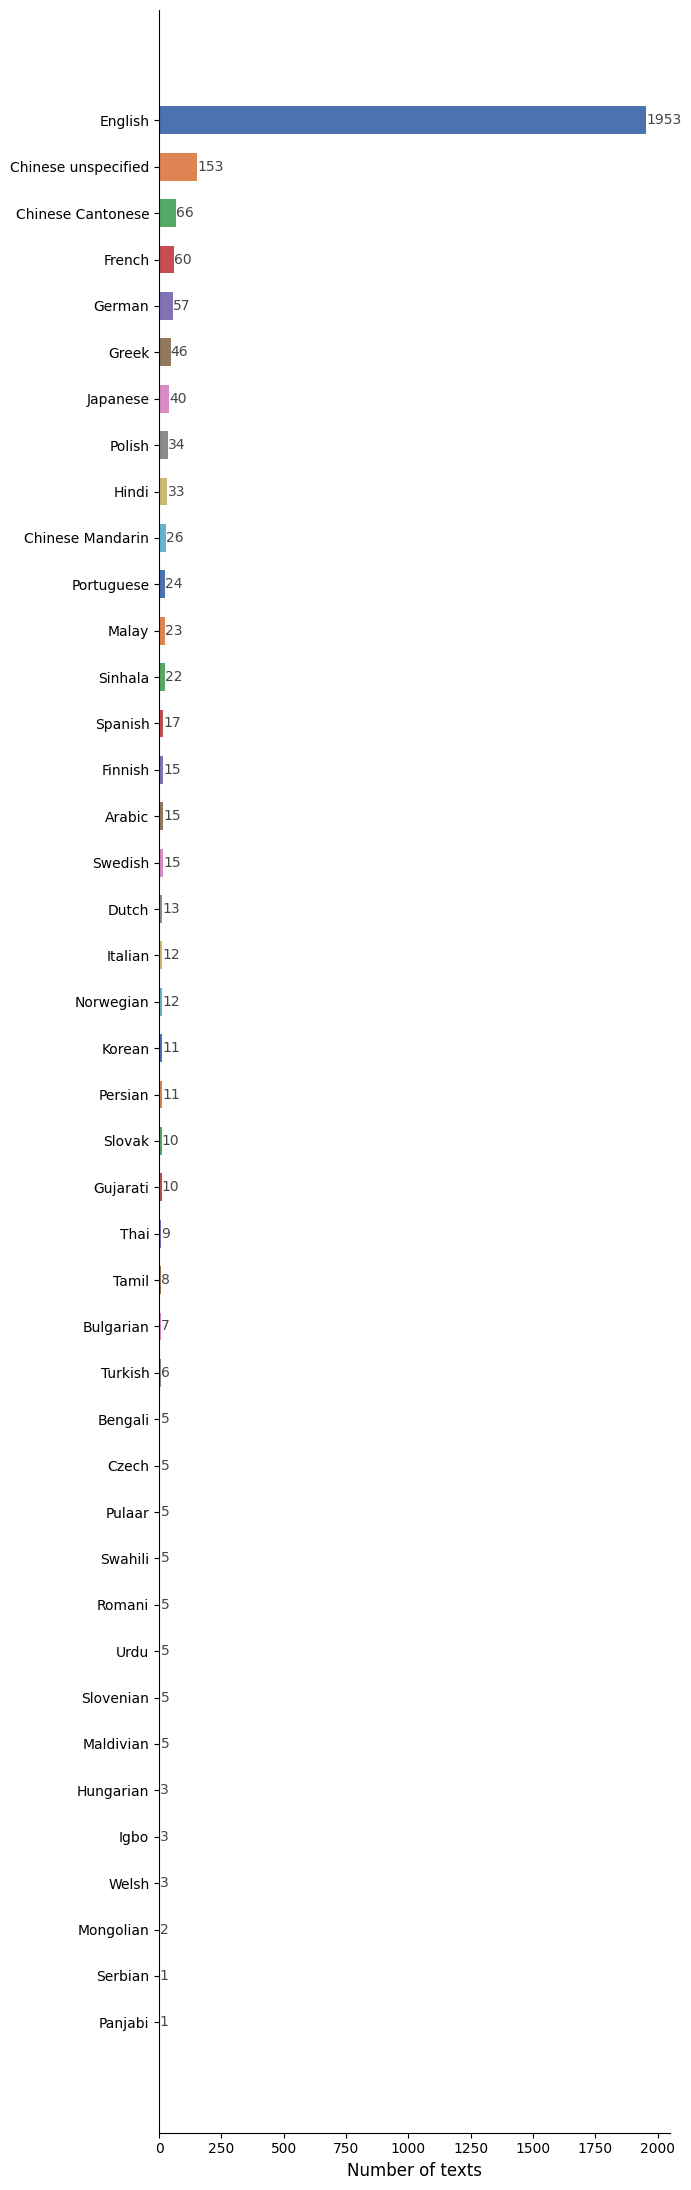

In [ ]:
plot_category(meta_data_df,"languages")

Plotting the language distribution (English removed)

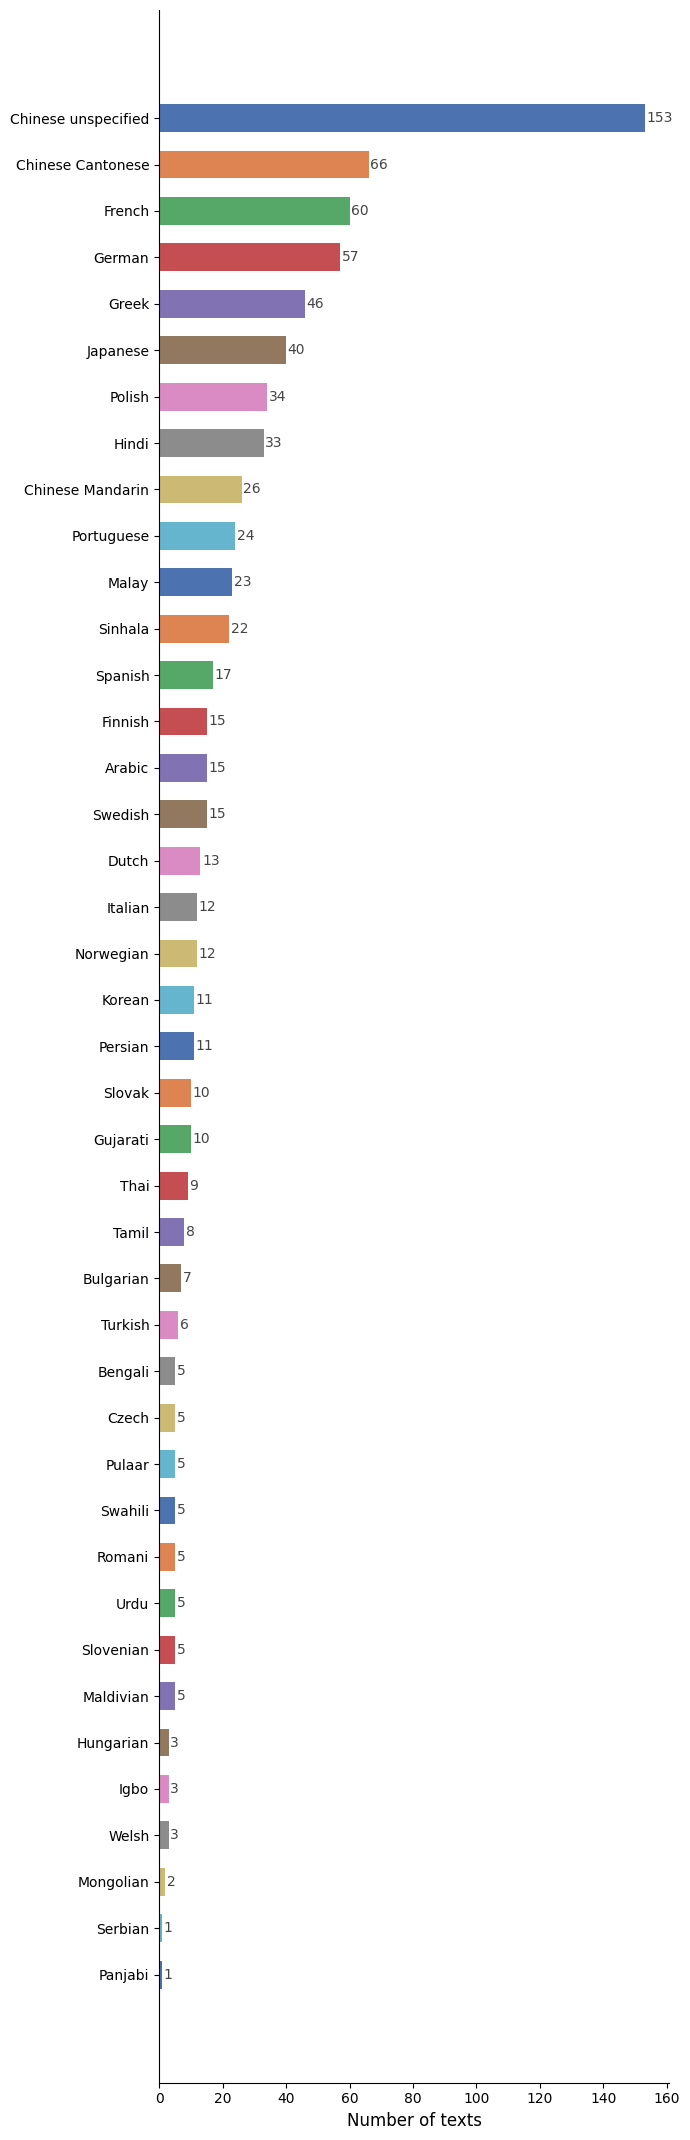

In [ ]:

meta_data_df_no_eng = meta_data_df[meta_data_df["languages"] != "English"]
plot_category(meta_data_df_no_eng,"languages")

Plotting the topic (discipline) distribution

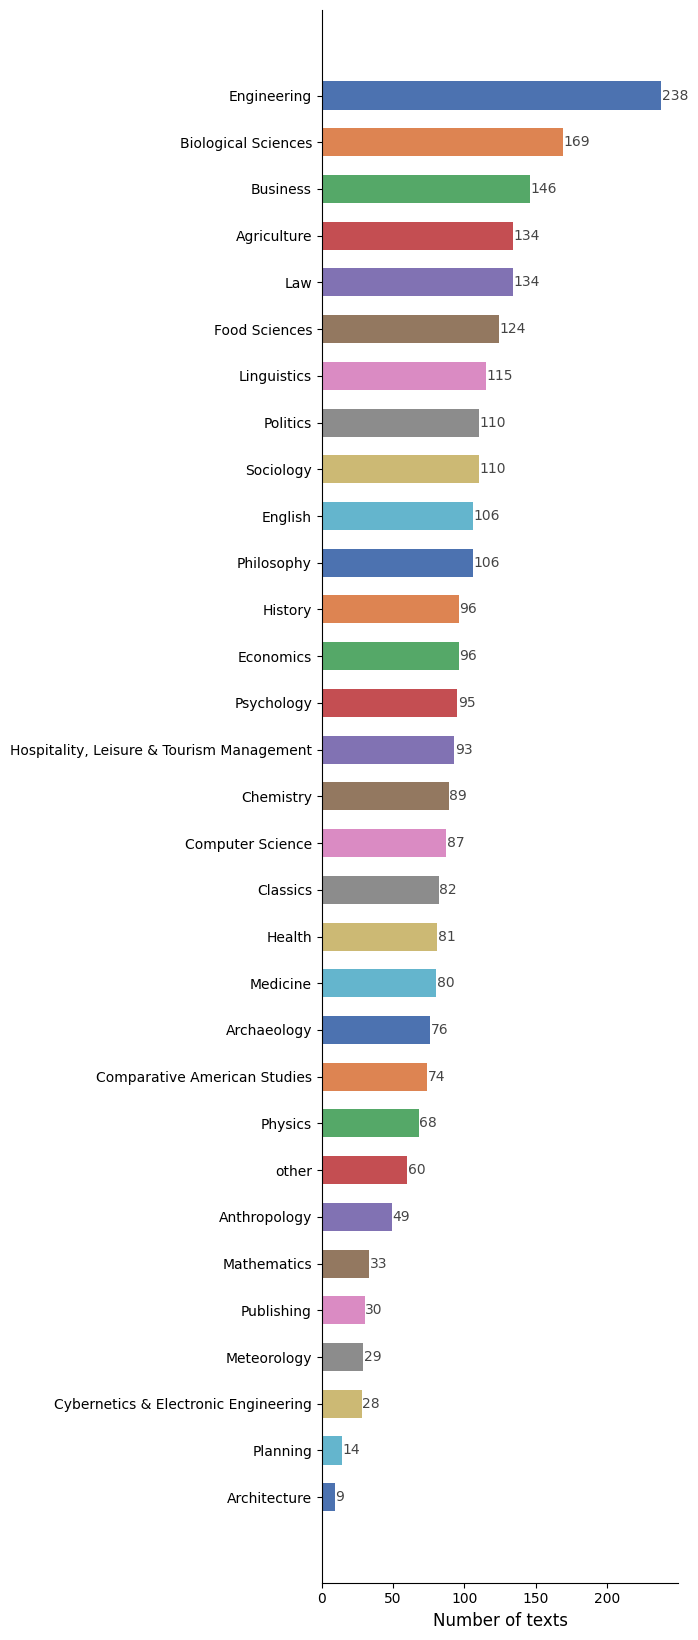

In [ ]:
plot_category(meta_data_df, "disc")

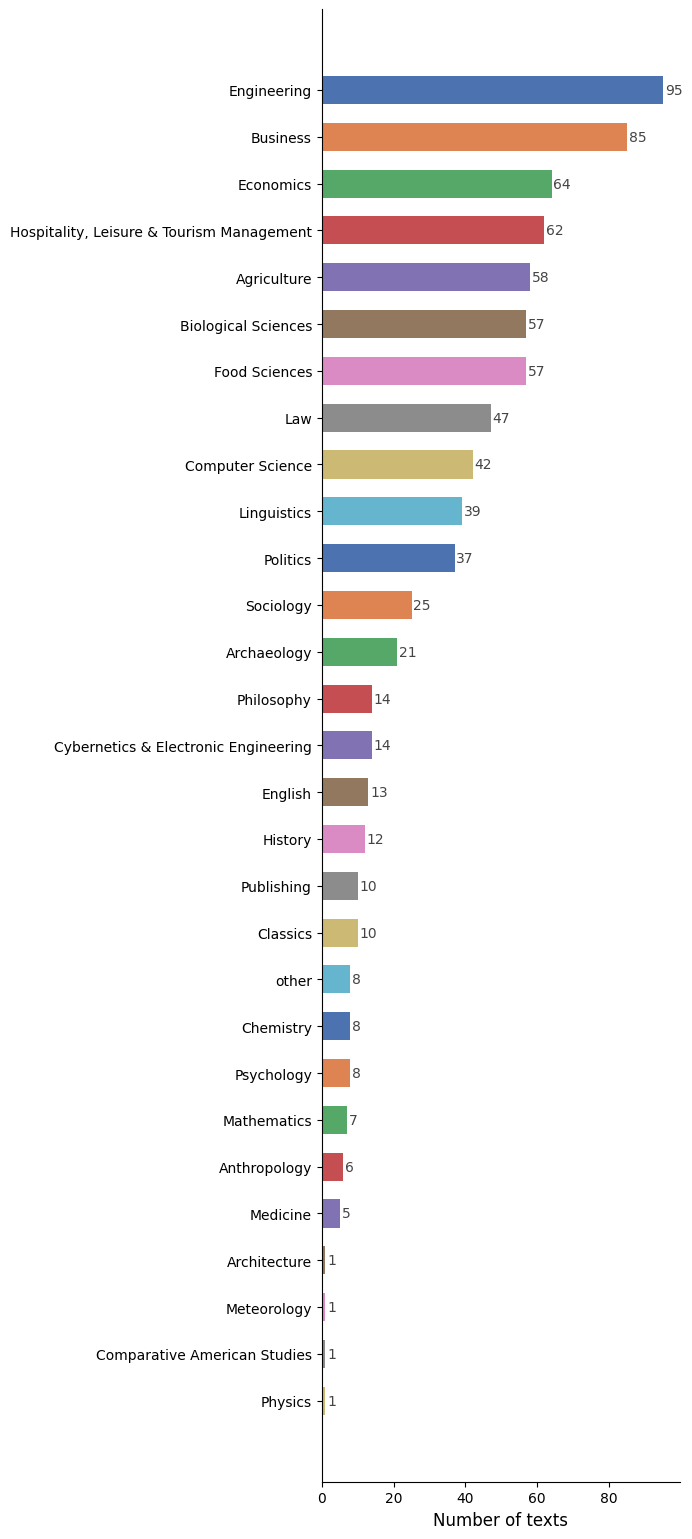

In [ ]:
plot_category(meta_data_df_no_eng, "disc")

As visible above, removing texts written by native English speakers actually changes the distribution of disciplines. Therefore, for the four languages we pick, we can look at co-occurence counts and correlation, to see if the discipline could potentially act as a confounder (in the case where some L1 languages appear more in specific fields)


In [ ]:
meta_data_df_no_eng = meta_data_df[meta_data_df["languages"].isin(["Chinese Mandarin", "French", "German", "Japanese"])]

In [ ]:
pd.crosstab(meta_data_df_no_eng["languages"], meta_data_df_no_eng["disc"], normalize="index")

disc,Agriculture,Archaeology,Biological Sciences,Business,Classics,Computer Science,Economics,Engineering,English,History,"Hospitality, Leisure & Tourism Management",Law,Linguistics,Physics,Politics,Sociology,other
languages,,,,,,,,,,,,,,,,,
Chinese Mandarin,0.000000,0.000000,0.153846,0.269231,0.0,0.000000,0.076923,0.153846,0.000000,0.000000,0.000000,0.000000,0.192308,0.000000,0.000000,0.153846,0.000000
French,0.000000,0.016667,0.066667,0.000000,0.0,0.216667,0.133333,0.000000,0.150000,0.000000,0.050000,0.183333,0.016667,0.000000,0.166667,0.000000,0.000000
German,0.087719,0.000000,0.105263,0.070175,0.0,0.035088,0.035088,0.000000,0.070175,0.017544,0.280702,0.035088,0.175439,0.017544,0.017544,0.000000,0.052632
Japanese,0.250000,0.175000,0.125000,0.000000,0.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.025000,0.000000,0.225000,0.000000,0.000000,0.000000,0.000000


As seen above, some disciplines have higher rates of occurence with one language (e.g Agriculture and Classics with Japanese), while others are more evenly distributed (linguistics). This is especially relevant since (as mentionned in [this survey paper](https://aclanthology.org/2024.naacl-long.173.pdf)), topic can add a confounding effect. Therefore, we will attempt to reduce this problem during sampling

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(meta_data_df_no_eng["languages"], meta_data_df_no_eng["disc"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"chi2={chi2:.3f}, p={p:.4f}, dof={dof}")

import numpy as np

n = contingency_table.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"Cramér's V={cramers_v:.3f}")

chi2=259.610, p=0.0000, dof=48
Cramér's V=0.688


Average number of words by language

In [ ]:
df_word_count = meta_data_df_no_eng.groupby("languages")["nb words"].mean()
print(df_word_count)

languages
Chinese Mandarin    2513.000000
French              2530.416667
German              2573.526316
Japanese            2138.200000
Name: nb words, dtype: float64


In [ ]:
meta_data_df_no_eng.groupby("languages")["nb words"].describe()

,count,mean,std,min,25%,50%,75%,max
languages,,,,,,,,
Chinese Mandarin,26.0,2513.000000,1259.804620,833.0,1663.75,2304.0,3169.75,5114.0
French,60.0,2530.416667,1768.829559,655.0,1572.75,2002.0,2969.50,11375.0
German,57.0,2573.526316,1505.384480,608.0,1508.00,2164.0,3235.00,6952.0
Japanese,40.0,2138.200000,856.585535,576.0,1500.75,2013.0,2884.25,3837.0


From the tables above, we can see that the mean word count is actually similar accross all the languages except for Japanese, whose 3rd percentile average is lower than that of the other languages, and has a lower standard deviation overall. Despite this, the mean is fairly similar across all languages, and therefore we will not be taking additional steps in include word count into sampling.

In [ ]:
target_langs = ['French', 'German', 'Chinese Mandarin', 'Japanese']
L1s_dict = (meta_data_df[meta_data_df['languages'].isin(target_langs)]
            .groupby('languages')['paths'].apply(list).to_dict())

In order to be able to establish a parallel comparison with the CzeSL corpus, we actually split each text in chunks of around 200 words, so that it matches the average length of a text from the CzESL corpus. We use punctuation POS tags in order to determine where a sentence should be split, maintaining the integrity of the text.
The format for grakel function creates nodes with the head and children of the dependency relations, which we will later use for the classification with graph kernels.

In [ ]:


def read_data_chunk(xml_file, csv_path, lang):
    lang, nb, disc, path = meta_data(xml_file)

    csv_filepath = os.path.join(csv_path, xml_file.split("/")[-1].replace(".xml", ".csv"))
    df = pd.read_csv(csv_filepath)

    speaker_files = []
    file_id = xml_file.split("/")[-1].replace(".xml", "")

    start = 0
    while start < len(df):
        end = start + 250

        if end >= len(df):
            chunk = df.iloc[start:]
        else:
            if df.iloc[end]["pos"] == ".":
                chunk = df.iloc[start:end + 1]
                end = end + 1
            else:
                rest = df.iloc[end:]
                punct_rows = rest[rest["pos"] == "."].index
                if len(punct_rows) == 0:
                    chunk = df.iloc[start:]
                    end = len(df)
                else:
                    next_punct = punct_rows[0]
                    chunk = df.iloc[start:next_punct + 1]
                    end = next_punct + 1

        text    = " ".join([str(i) for i in chunk["word"].to_list()])
        text_tokenized = detok.detokenize(text)
        #lemmas  = " ".join([str(i) for i in chunk["lemma"].to_list()])
        pos     = " ".join(chunk["pos"].to_list())
        dep     = " ".join(chunk["dep"].to_list())

        # Raw columns needed for GRakel:
        txt =[str(i) for i in chunk["word"].to_list()]
        lemm = chunk["lemma"].to_list()
        pos = chunk["pos"].to_list()
        dep_on = chunk["dep_on"].to_list()
        dep = chunk["dep"].to_list()
        temp_df = pd.DataFrame({
    "word": txt,
    "lemma": lemm,
    "_pos" : ["_"] *len(txt),
    "pos": pos,
    "_dep":  ["_"] *len(txt),
    "dep_on": dep_on,
    "dep": dep,
    "_other" : ["_"] *len(txt),
    "_again": ["_"] *len(txt)
})
        str_conll = temp_df.to_string(header = False)
        actual_sent = detok.detokenize(txt) + "\n"
        str_conll = f"# text = {actual_sent}\n" + temp_df.to_csv(sep='\t', header=False)
        deprels = conllu.parse(str_conll,fields=["id", "form", "lemma", "_", "upos", "_", "head", "deprel", "_", "_"])
        lemm = [str(i) for i in lemm]
        lemma = detok.detokenize(lemm)
        pos = " ".join(chunk["pos"].to_list())
        dep = " ".join(chunk["dep"].to_list())






        speaker_files.append({
            "id": file_id,
            "sentences": text,
            "lemmas": lemma,
            "pos": pos,
            "dep": dep,
            "deprel": deprels,
            "labels": lang,
            "discipline": disc
        })

        start = end

    return speaker_files


def format_for_grakel(deprels, labels):

    count_nodes = 1
    deprel_labels = dict()
    upos_labels= dict()

    Gs= []

    for deprel in deprels:
        edges = set()
        nodes_dict = dict()
        edges_dict = dict()

        for tok in deprel:
            for i in tok:

                if i["upos"] not in upos_labels.keys():
                        upos_labels[i["upos"]] = len(upos_labels)

                node_id = count_nodes

                if i["head"] != 0:
                    if i["deprel"] not in deprel_labels.keys():
                        deprel_labels[i["deprel"]] = len(deprel_labels)

                    new_head_id = (count_nodes-i["id"]) + i["head"]
                    edges.add((new_head_id,node_id))
                    edges_dict[(new_head_id, node_id)] = deprel_labels[i["deprel"]]
                    nodes_dict[node_id] = upos_labels[i["upos"]]
                else:
                    nodes_dict[node_id] = upos_labels[i["upos"]]

                count_nodes = count_nodes+1

        Gs.append([edges, nodes_dict, edges_dict])

    return Bunch(data= Gs[1:len(Gs)], target= labels[1:len(labels)])






In [ ]:
dfs = []
for i in L1s_dict.keys():
  print(i)
  for j in L1s_dict[i]:


      dfs.extend(read_data_chunk(j,eng_csv_folder,i))

# Saving to Grakel data
deprels = [i["deprel"] for i in dfs]
labels = [i["labels"] for i in dfs]
grakel_format = format_for_grakel(deprels, labels)
grakel_format_csv = pd.DataFrame(data = {"data": grakel_format.data, "labels": grakel_format.target})
print(grakel_format_csv)



Chinese Mandarin
French
German
Japanese
                                                   data            labels
0     [{(266, 268), (294, 403), (266, 332), (272, 43...  Chinese Mandarin
1     [{(601, 820), (613, 611), (570, 713), (562, 73...  Chinese Mandarin
2     [{(844, 1020), (844, 846), (844, 855), (830, 9...  Chinese Mandarin
3     [{(1125, 1216), (1148, 1218), (1122, 1318), (1...  Chinese Mandarin
4     [{(1397, 1556), (1415, 1418), (1407, 1414), (1...  Chinese Mandarin
...                                                 ...               ...
1920  [{(491726, 491724), (491714, 491942), (491721,...          Japanese
1921  [{(491993, 492013), (491988, 492008), (491998,...          Japanese
1922  [{(492263, 492301), (492255, 492416), (492277,...          Japanese
1923  [{(492545, 492572), (492536, 492569), (492561,...          Japanese
1924  [{(492781, 492779), (492791, 492850), (492791,...          Japanese

[1925 rows x 2 columns]


In [ ]:
dfs = pd.json_normalize(dfs)
print(dfs.head())

      id                                          sentences  \
0  0025a  The main objective of this experiment is to us...   
1  0025a  When bridge circuit is in balance , both poten...   
2  0025a  Since FORMULA As shown left -LRB- Figure 3 -RR...   
3  0025a  Then plot a graph according to the records . A...   
4  0025a  Rearrange the equation above then get FORMULA ...   

                                              lemmas  \
0  the main objective of this experiment be to us...   
1  when bridge circuit be in balance, both potent...   
2  since formula as show left -lrb- figure 3 -rrb...   
3  then plot a graph accord to the record. after ...   
4  rearrange the equation above then get formula ...   

                                                 pos  \
0  DT JJ NN IN DT NN VBZ TO VB DT NN NN TO VB DT ...   
1  WRB NN NN VBZ IN NN , CC JJ NNS VBP JJ , RB DT...   
2  IN NN IN VBN NN -LRB- NN CD -RRB- , NN , NN , ...   
3  RB NN DT NN VBG TO DT NNS . IN VBG DT NN NN IN...   
4  V

In [ ]:
pd.crosstab(dfs["labels"], dfs["discipline"])

discipline,Agriculture,Archaeology,Biological Sciences,Business,Classics,Computer Science,Economics,Engineering,English,History,"Hospitality, Leisure & Tourism Management",Law,Linguistics,Physics,Politics,Sociology,other
labels,,,,,,,,,,,,,,,,,
Chinese Mandarin,0,0,34,70,0,0,19,30,0,0,0,0,47,0,0,85,0
French,0,9,61,0,0,134,67,0,94,0,73,115,8,0,82,0,0
German,62,0,68,30,0,15,26,0,38,8,257,14,85,11,6,0,16
Japanese,105,65,37,0,87,0,0,0,0,0,8,0,60,0,0,0,0


As seen in the new co-occurence matrix obtained after chunking and sampling our languages, "Biological Sciences" and "Linguistics" are the only two domains which are represented in each language sample, and we will thus have to include them both in order to mitigate the impact of the topic discipline

In [ ]:
def sample_balanced(df, label_col="labels", discipline_col="discipline", n_per_cell=150, min_cell_size=3):

    sampled = (
        df.groupby([label_col, discipline_col], group_keys=False)
        .filter(lambda x: len(x) >= min_cell_size)
        .groupby([label_col, discipline_col], group_keys=False)
        .apply(lambda x: x.sample(min(n_per_cell, len(x)), random_state=42))
    )
    return sampled.reset_index(drop=True)

disciplines_per_lang = dfs.groupby("labels")["discipline"].unique()
common_disciplines = set.intersection(*[set(d) for d in disciplines_per_lang])
print("Common disciplines:", common_disciplines)

balanced_bawe = sample_balanced(
    dfs[dfs["discipline"].isin(common_disciplines)]
)



Common disciplines: {'Biological Sciences', 'Linguistics'}


/tmp/ipykernel_1627/2238927683.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n_per_cell, len(x)), random_state=42))


In [ ]:
print(pd.crosstab(balanced_bawe["labels"], balanced_bawe["discipline"]))

discipline        Biological Sciences  Linguistics
labels                                            
Chinese Mandarin                   34           47
French                             61            8
German                             68           85
Japanese                           37           60


In [ ]:
bawe_dataset = balanced_bawe.sample(frac=1)

Data Processing: CZESL corpus

The CSZESL, or Czech as a Second Language was compiled and distributed by [Charles University](https://ufal.mff.cuni.cz/czesl). It is available in csv format, and contains word and lemma level annotations. The texts were written by foreign students attending Czech language classes at universities. In order to be able to extract linguistic features, we use the Stanza tools again in order to obtain POS and dependency level tagged version of the texts.

Data Pre-processing

In [ ]:
import torch
import stanza

use_gpu = torch.cuda.is_available()

print("GPU available:", use_gpu)
if use_gpu:
    print("Device:", torch.cuda.get_device_name(0))

nlp = stanza.Pipeline(
    lang="cs",
    use_gpu=use_gpu
)

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


GPU available: False


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json


INFO:stanza:Loading these models for language: cs (Czech):
| Processor | Package      |
----------------------------
| tokenize  | pdt          |
| mwt       | pdt          |
| pos       | pdt_nocharlm |
| lemma     | pdt_nocharlm |
| depparse  | pdt_nocharlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


In [ ]:
import xml.etree.ElementTree as ET


In [ ]:
from sacremoses import MosesTokenizer, MosesDetokenizer
tok, detok = MosesTokenizer(lang='cs'), MosesDetokenizer(lang='cs')

In [ ]:
xml_filename = cz_file

language_map = {
    'ru': 'Russian',
    'zh': 'Chinese',
    'uk': 'Ukrainian',
    'ko': 'Korean',
    'en': 'English',
    'ja': 'Japanese',
    'kk': 'Kazakh',
    'de': 'German',
    'fr': 'French',
    'es': 'Spanish',
    'vi': 'Vietnamese',
    'ar': 'Arabic',
    'pl': 'Polish',
    'tr': 'Turkish',
    'it': 'Italian',
    'mn': 'Mongolian',
    'uz': 'Uzbek',
    'ky': 'Kyrgyz',
    'hu': 'Hungarian',
    'ro': 'Romanian',
    'be': 'Belarusian',
    'th': 'Thai',
    'bg': 'Bulgarian',
    'az': 'Azerbaijani',
    'nl': 'Dutch',
    'fi': 'Finnish',
    'mk': 'Macedonian',
    'mo': 'Moldovan',
    'sq': 'Albanian',
    'el': 'Greek',
    'pt': 'Portuguese',
    'he': 'Hebrew',
    'fa': 'Persian',
    'sv': 'Swedish',
    'ba': 'Bashkir',
    'lv': 'Latvian',
    'da': 'Danish',
    'sk': 'Slovak',
    'tl': 'Tagalog',
    'ka': 'Georgian',
    'sr': 'Serbian',
    'hy': 'Armenian',
    'hr': 'Croatian',
    '': 'Unknown',
    'hi': 'Hindi',
    'xal': 'Kalmyk',
    'kg': 'Kongo',
    'sl': 'Slovenian',
    'id': 'Indonesian',
    'sh': 'Serbo-Croatian',
    'tg': 'Tajik',
    'no': 'Norwegian',
    'la': 'Latin',
    'ms': 'Malay'
}





class XMLCorpusProcessor:
    def __init__(self, path):
        self.path = path
        self.root = ET.parse(self.path).getroot()
        self.divisions = self.root.findall(".//div")

    def filter_valid_entries(self):
        self.filtered_divisions = [
            d for d in self.divisions
            if d.get("s_l1") != "" and d.get("s_cz_CEF") != ""
        ]

    def filter_by_word_count(self, threshold):
        filtered = []
        for d in self.filtered_divisions:
            if int(d.get("t_words_count")) > threshold:
                filtered.append(d)
        self.filtered_divisions = filtered

    def filter_by_attributes(self, criteria):
        for key in criteria.keys():
            values = criteria[key]
            self.filtered_divisions = [
                d for d in self.filtered_divisions if d.get(key) in values
            ]


def convert_to_dataframe(divisions, detok):
    user_ids = [d.get("s_id") for d in divisions]
    languages = [d.get("s_L1") for d in divisions]
    word_counts = [d.get("t_words_count") for d in divisions]
    text_ids = [d.get("t_id") for d in divisions]
    cef_levels = [d.get("s_cz_CEF") for d in divisions]

    words_data = [d.findall(".//word") for d in divisions]

    raw_sentences = []
    corrected_sentences = []
    lemma_sentences = []
    error_data = []

    for sentence in words_data:
        words = []
        corrected = []
        lemmas = []
        errors = []

        for token in sentence:
            words.append(token.text)
            corrected.append(token.get("word1"))
            lemmas.append(token.get("lemma1"))

            err = token.get("err")
            if "|" in str(err):
                err = err.split("|")
            errors.append(err)

        raw_sentences.append(words)
        corrected_sentences.append(corrected)
        lemma_sentences.append(lemmas)
        error_data.append(errors)

    raw_sentences = [detok.detokenize(s) for s in raw_sentences]
    corrected_sentences = [detok.detokenize(s) for s in corrected_sentences]
    lemma_sentences = [" ".join(s) for s in lemma_sentences]

    cleaned_errors = []
    for entry in error_data:
        temp = []
        for e in entry:
            if isinstance(e, str) and e != "":
                temp.append(e)
            elif isinstance(e, list):
                temp.extend(e)
        cleaned_errors.append(temp)

    df = pd.DataFrame({
        "text_id": text_ids,
        "user": user_ids,
        "level": cef_levels,
        "L1": languages,
        "word_count": word_counts,
        "sentence": raw_sentences,
        "sentence_corrected": corrected_sentences,
        "errors": cleaned_errors,
        "lemmas": lemma_sentences,
        "word_count": word_counts
    })

    df["L1"] = df["L1"].map(language_map)

    return df


In [ ]:
processor = XMLCorpusProcessor(cz_file)
processor.filter_valid_entries()
processor.filter_by_word_count(0)

df = convert_to_dataframe(processor.filtered_divisions, detok)
print(df)

          text_id     user level         L1 word_count  \
0      DGD_H2_336   DGD_H2    A2  Ukrainian        247   
1      TES_VA_005   TES_VA    B1    Russian         72   
2     UJA3_TV_003  UJA3_TV    A1    Russian         50   
3     TES2_SD_005  TES2_SD    B1    Turkish        142   
4     UJA2_4P_005  UJA2_4P    A1  Ukrainian         73   
...           ...      ...   ...        ...        ...   
7937   UJA_SF_001   UJA_SF    B1   Japanese         57   
7938   SME_M1_007   SME_M1    B2    Russian        145   
7939  UJA2_P2_006  UJA2_P2    B1     Korean        167   
7940   TTD_M4_228   TTD_M4    A1    Russian        130   
7941   NEM_MA_003   UJA_MA    A2    Russian         96   

                                               sentence  \
0     Životní styl, kultura, služby v ČR a v me zemi...   
1     Zakázat kouření v restauracích je to velka otá...   
2     Ahoj Evo! Ják se máš? Jsem v Praze. Mám nový b...   
3     JÁ A STUDIUM ČEŠTINY Jsem z Turecka, ale už še...   
4     Na

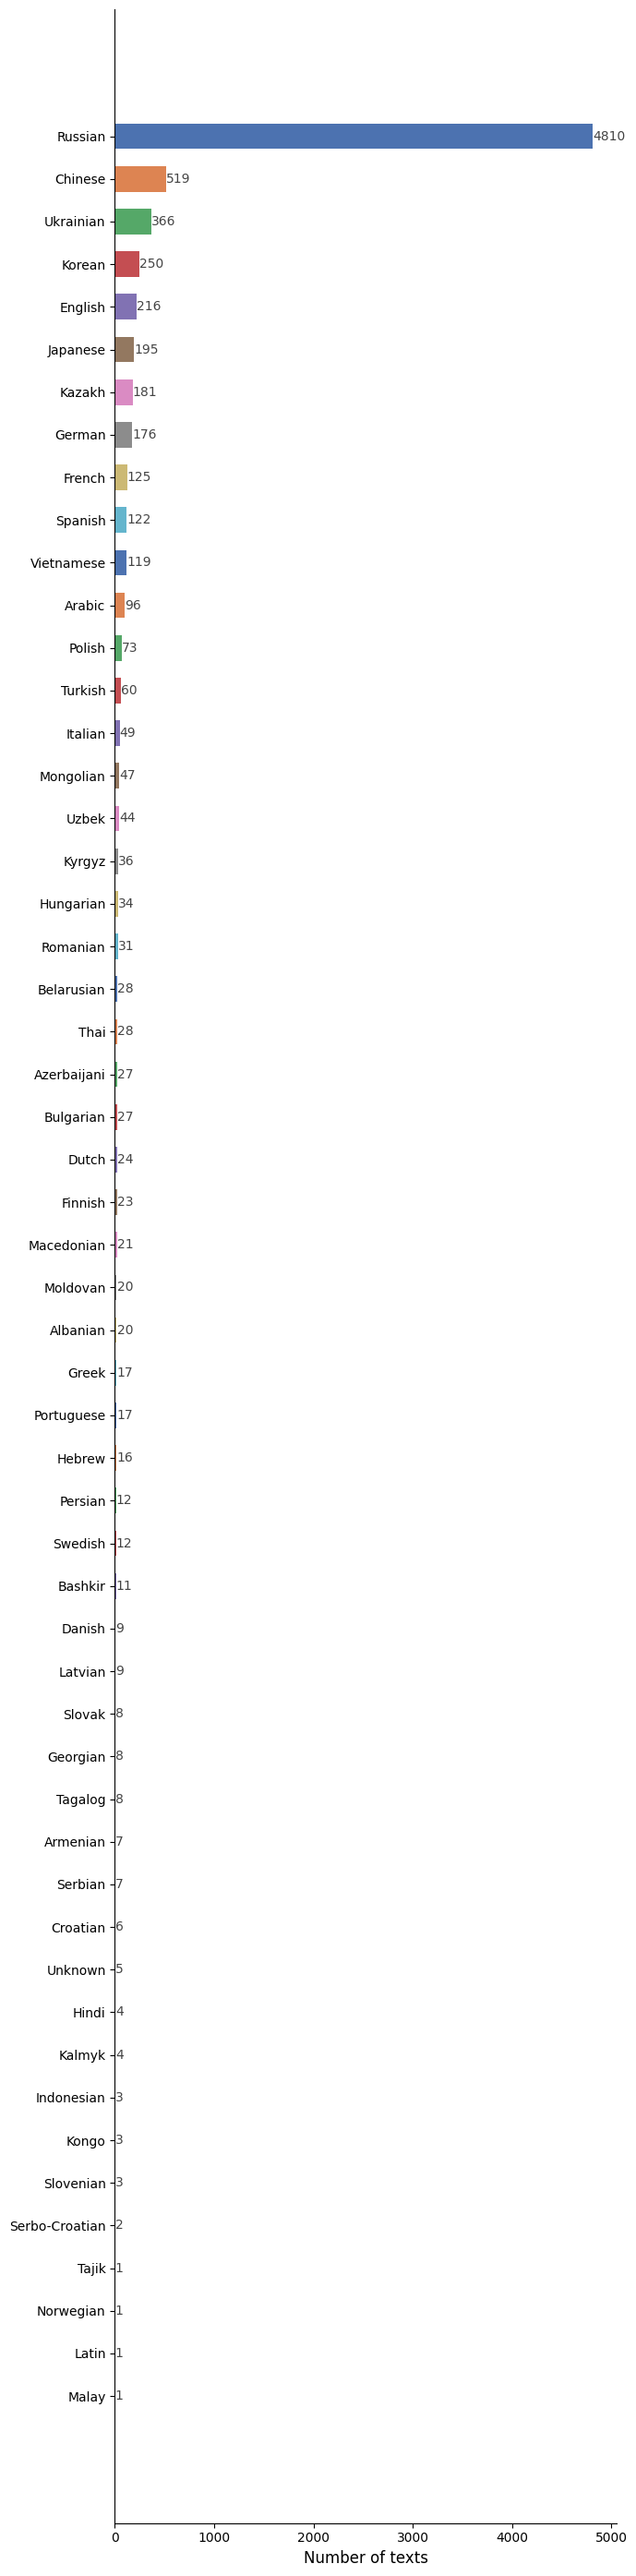

In [ ]:
plot_category(df,"L1")

As seen above, the majority of the texts in the corpus is actually in Russian, but our target languages seem to be fairly well represented

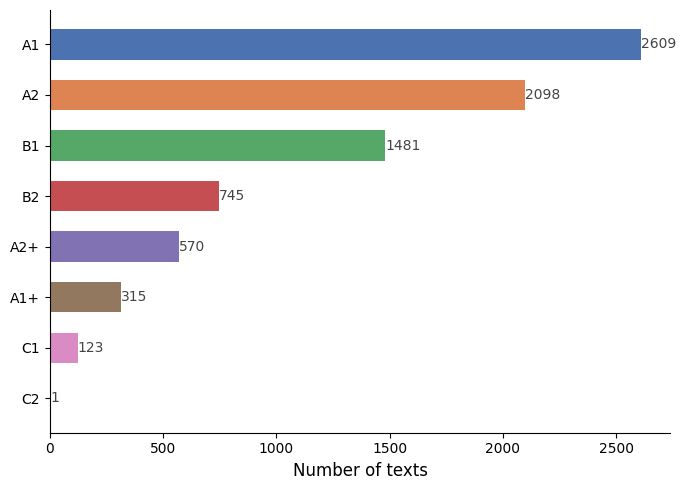

In [ ]:
plot_category(df,"level")

A1 level texts are overrepresented in the corpus. We discard A1-level texts since it is likely that they will contain less speaker-variance accross languages, due to the low proficiency level

In [ ]:
from collections import Counter
def extract_error_dataframe(divisions):
    words_data = [d.findall(".//word") for d in divisions]
    records = []

    for i, div in enumerate(divisions):
        user = div.get("s_id")
        language = div.get("s_L1")
        level = div.get("s_cz_CEF")
        text_id = div.get("t_id")

        indices = [
            j for j, token in enumerate(words_data[i])
            if token.get("err") != ""
        ]

        for idx in indices:
            err = words_data[i][idx].get("err")
            if "|" in str(err):
                err = err.split("|")
            else:
                err = [err]

            for e in err:
                records.append((
                    text_id,
                    user,
                    language,
                    level,
                    e,
                    words_data[i][idx].text,
                    words_data[i][idx].get("word1")
                ))

    return pd.DataFrame(
        records,
        columns=["text_id", "user", "L1", "level", "error", "word", "correction"]
    )


def filter_dataframe(df, criteria):
    for key in criteria.keys():
        df = df[df[key].isin(criteria[key])]
    return df


def count_languages(df):
    return Counter(df["L1"].to_list())


def sample_group(group, n):
    if len(group) > n:
        return group.sample(n)
    return group


def balance_dataset(df, error_df, drop_missing):

    target_size = Counter(df["L1"].to_list()).most_common()[1][1]

    #grouped = df.groupby("L1", group_keys=False)
    balanced_dfs = []
    for l1, group in df.groupby("L1"):
        balanced_dfs.append(group.sample(min(len(group), target_size)))
    balanced_df = pd.concat(balanced_dfs).reset_index(drop=True)
    ids = list(set(balanced_df["text_id"].to_list()))

    filtered_errors = error_df[error_df["text_id"].isin(ids)]

    missing = set(ids) - set(filtered_errors["text_id"].to_list())

    if drop_missing:
        balanced_df = balanced_df[~balanced_df["text_id"].isin(missing)]

    return balanced_df, filtered_errors


In [ ]:

def clean_text(text):
    text = " ".join(re.findall(r"[\w]+", text))
    text = re.sub(r"\d+", "", text)
    text = re.sub(" +", " ", text)
    return text.lower()


def preprocess_column(df, column):
    df[column] = df[column].apply(clean_text)
    return df[column].to_list()


def avg_sentence_length(text):
    return len(text)


def extract_linguistic_features(df, column,nlp_pipeline):
    texts = preprocess_column(df, column)

    upos_outputs = []
    deprel_outputs = []

    for text in texts:
        doc = nlp_pipeline(text)
        upos_outputs.append(" ".join([w.upos for w in doc.iter_words()]))
        deprel_outputs.append(" ".join([w.deprel for w in doc.iter_words()]))

    return deprel_outputs, upos_outputs


In [ ]:
criteria = {"level":["A2", "B1", "B2"], "L1":["French","German","Chinese","Japanese"]}

In [ ]:
error_df = extract_error_dataframe(processor.filtered_divisions)

df = filter_dataframe(df, criteria)

balanced_df, filtered_error_df = balance_dataset(df, error_df, True)

In [ ]:
print(balanced_df.head())

       text_id     user level       L1 word_count  \
0   UJA_ZN_004   UJA_ZN    B1  Chinese         79   
1  UJA2_ZW_008  UJA2_ZW    B1  Chinese        141   
2  UJA2_NY_008  UJA2_NY    A2  Chinese        233   
3  UJA2_NY_003  UJA2_NY    A2  Chinese        109   
4  UJA2_H3_005  UJA2_H3    A2  Chinese         81   

                                            sentence  \
0  Moje nejhezčí vzpomínka z dětství Už nepamáduj...   
1  Vybral jsem si témata C. Podle mého názoru, že...   
2  Moje nejlepší kamarádka Když jsem studovala na...   
3  Jak se máš? Já jsem vyborně v Praze. Každy den...   
4  Objednala jsem hovězí polevku, špagety a medov...   

                                  sentence_corrected  \
0  Moje nejhezčí vzpomínka z dětství Už nepamatuj...   
1  Vybral jsem si témata. podle mého názoru, že s...   
2  Moje nejlepší kamarádka Když jsem studovala na...   
3  Jak se máš? Já jsem výborně v Praze. Každý den...   
4  Objednala jsem hovězí polévku, špagety a medov...   

       

Tagging the CzESL corpus with the Stanza tools (note: this may take up to 10 minutes if no GPU is available)

In [ ]:
sentences = preprocess_column(df, "sentence")
deprel, upos = extract_linguistic_features(df, "sentence", nlp)
df = {
        "sentences": sentences,
        "labels": df["L1"].to_list(),
        "dep": deprel,
        "upos": upos,
        "lemmas": df["lemmas"].to_list()
    }

In [ ]:
czech_df = pd.DataFrame.from_dict(df)


In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(balanced_df["L1"], balanced_df["level"])
print(contingency_table)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"chi2={chi2:.3f}, p={p:.4f}, dof={dof}")

import numpy as np

n = contingency_table.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"Cramér's V={cramers_v:.3f}")

level     A2  B1  B2
L1                  
Chinese   66  48  11
French    37  15  29
German    41  54  11
Japanese  29  68  22
chi2=56.838, p=0.0000, dof=6
Cramér's V=0.257


We observe that there is a correlation between native language and CEFR level, which we keep in mind for later (due to the small quantity of data available, downsampling would have a negative effect on training)

In [ ]:
balanced_df.head()

,text_id,user,level,L1,word_count,sentence,sentence_corrected,errors,lemmas
0,UJA_ZN_004,UJA_ZN,B1,Chinese,79,Moje nejhezčí vzpomínka z dětství Už nepamáduj...,Moje nejhezčí vzpomínka z dětství Už nepamatuj...,"[Quant1, Voiced, Mne0, Quant1, Quant0, Quant0,...",můj hezký vzpomínka z dětství už pamatovat svů...
1,UJA2_ZW_008,UJA2_ZW,B1,Chinese,141,"Vybral jsem si témata C. Podle mého názoru, že...","Vybral jsem si témata. podle mého názoru, že s...","[Head1, Cap1, Quant0, Quant1, Quant0, Caron0, ...","vybrat být se téma . podle můj názor , že skor..."
2,UJA2_NY_008,UJA2_NY,A2,Chinese,233,Moje nejlepší kamarádka Když jsem studovala na...,Moje nejlepší kamarádka Když jsem studovala na...,"[Quant0, Quant1, MissChar, Quant0, Quant1, Qua...",můj dobrý kamarádka když být studovat na unive...
3,UJA2_NY_003,UJA2_NY,A2,Chinese,109,Jak se máš? Já jsem vyborně v Praze. Každy den...,Jak se máš? Já jsem výborně v Praze. Každý den...,"[Quant0, Quant0, MissChar, Quant0, SingCh, Qua...",jak se mít ? já být výborně v Praga . každý de...
4,UJA2_H3_005,UJA2_H3,A2,Chinese,81,"Objednala jsem hovězí polevku, špagety a medov...","Objednala jsem hovězí polévku, špagety a medov...","[Quant0, Quant0, Quant0, Voiced, Quant0, Quant...","objednat být hovězí polévka , špageta a medovn..."


In [ ]:
balanced_df["word_count"] =[int(i) for i in balanced_df["word_count"].to_list()]

In [ ]:
df_word_count = balanced_df.groupby("L1")["word_count"].mean()
print(df_word_count)

L1
Chinese     131.432000
French       99.345679
German      134.207547
Japanese    119.487395
Name: word_count, dtype: float64


In [ ]:
balanced_df.groupby("L1")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
L1,,,,,,,,
Chinese,125.0,131.432000,124.741108,13.0,64.00,90.0,141.00,915.0
French,81.0,99.345679,66.029759,30.0,56.00,84.0,116.00,379.0
German,106.0,134.207547,73.660963,41.0,79.25,112.5,169.75,442.0
Japanese,119.0,119.487395,70.824666,25.0,73.50,101.0,142.00,459.0


Processed CzESL data for Grakel

In [ ]:
from nltk.tokenize import WhitespaceTokenizer


Note: This also uses the Stanza parser and therefore takes some time to run if there is no GPU access

In [ ]:
tokenizer = WhitespaceTokenizer()


uppercase_pattern = r"(\b[A-Z]+)"





def preprocess_document(text):
    title_parts = re.split(
        uppercase_pattern,
        text
    )

    if len(title_parts) < 2:
        cleaned_text = text
    else:
        title = (
            title_parts[0]
            + title_parts[1]
            + title_parts[2]
        )

        remaining_text = text.replace(
            title,
            ""
        )

        cleaned_text = (
            title.strip()
            + ". "
            + remaining_text
        )

    return cleaned_text



def process_data(dataset):
    document_labels = []

    node_offset = 1

    dependency_label_map = {}
    pos_label_map = {}

    graphs = []

    for _, row in dataset.iterrows():

        document_text = preprocess_document(
            row["sentences"]
        )

        parsed_document = nlp(
            document_text
        )

        for sentence in parsed_document.sentences:

            document_labels.append(
                row["labels"]
            )

            edge_set = set()
            node_labels = {}
            edge_labels = {}

            node_id_mapping = {}

            for dependency in sentence.dependencies:

                head_node = dependency[0]
                dependent_node = dependency[2]

                mapped_head_id = (
                    head_node.id
                    + node_offset
                )

                mapped_dependent_id = (
                    dependent_node.id
                    + node_offset
                )

                if (
                    head_node.id
                    not in node_id_mapping
                ):
                    node_id_mapping[
                        head_node.id
                    ] = mapped_head_id

                if (
                    dependent_node.id
                    not in node_id_mapping
                ):
                    node_id_mapping[
                        dependent_node.id
                    ] = mapped_dependent_id

                mapped_head_id = (
                    node_id_mapping[
                        head_node.id
                    ]
                )

                mapped_dependent_id = (
                    node_id_mapping[
                        dependent_node.id
                    ]
                )

                edge_set.add(
                    (
                        mapped_head_id,
                        mapped_dependent_id,
                    )
                )

                edge_set.add(
                    (
                        mapped_dependent_id,
                        mapped_head_id,
                    )
                )

                if (
                    head_node.deprel
                    not in dependency_label_map
                ):
                    dependency_label_map[
                        head_node.deprel
                    ] = len(
                        dependency_label_map
                    )

                if (
                    dependent_node.deprel
                    not in dependency_label_map
                ):
                    dependency_label_map[
                        dependent_node.deprel
                    ] = len(
                        dependency_label_map
                    )

                edge_labels[
                    (
                        mapped_head_id,
                        mapped_dependent_id,
                    )
                ] = dependency_label_map[
                    head_node.deprel
                ]

                edge_labels[
                    (
                        mapped_dependent_id,
                        mapped_head_id,
                    )
                ] = dependency_label_map[
                    dependent_node.deprel
                ]

                if (
                    mapped_dependent_id
                    not in node_labels
                ):
                    if (
                        dependent_node.upos
                        not in pos_label_map
                    ):
                        pos_label_map[
                            dependent_node.upos
                        ] = len(
                            pos_label_map
                        )

                    node_labels[
                        mapped_dependent_id
                    ] = pos_label_map[
                        dependent_node.upos
                    ]

                if (
                    mapped_head_id
                    not in node_labels
                ):
                    if (
                        head_node.upos
                        not in pos_label_map
                    ):
                        pos_label_map[
                            head_node.upos
                        ] = len(
                            pos_label_map
                        )

                    node_labels[
                        mapped_head_id
                    ] = pos_label_map[
                        head_node.upos
                    ]

                node_offset += 1

            graphs.append(
                (
                    edge_set,
                    node_labels,
                )
            )

        encoded_labels = (
            document_labels

        )

    return Bunch(
        data=graphs,
        target=encoded_labels,
    )

grakel_format_czech = process_data(czech_df)

CzESL: Errors analysis

CZESL corpus: Error annotations

The CzESL corpus also contains error annotations, providing the correct and learner version of each word when an error occurs. IN the 2014 corpus, which we use in this study, these annotations mainly concern the orthographical level. (the newer version of the corpus actual provides error annotations also on the syntactic and morphological level). This means that we get an extra dimension to analyze in comparison to the BAWE dataset. Because Czech orthography has a fairly straightforward phoneme-to-grapheme correspondence (vowel length and quality is at least explicit), this allows to see if the most frequent errors are partially linked to phonological features of the native languages of the participants: for instance, French and Chinese, in contrast to German and Japanese, do not have a vowel length distinction, and we would therefore expect German and Japanese learners of Czech to acquire length distinctions more naturally. A similar argument can be made about final consonant devoicing, which is also not made explicit in writing in German, as opposed to French. Other annotation types, however, are not directly related to linguistic features, but rather characteristics of the Latin writing system (e.g the error type which quantifies whether a word is correctly capitalized or not).

To look at error annotations, we first extract all the texts with at least one error, and copy the metadata accross rows, meaning that we have one row for each occuring error. We then group these errors by learner IDs, obtaining a summary of all the errors made by the learners. The next step is to then aggregate these errors by learner, and normalize each type by the total number of errors made by the respective learner, thus obtaining normalized frequencies of their occurence among the total error count. We can then compute the Mutual Information between the frequency of each error and their label. From this, we can see how much we can find out about the label from knowing the occurence frequency of a given error.

In [ ]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from operator import itemgetter

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
def build_error_vectors(df,error_types=None, binary=False):

    samples = []

    for text_id in set(df["text_id"].to_list()):
        feature_map = defaultdict(int, {k: 0 for k in error_types})

        subset = df.loc[df["text_id"] == text_id]

        for err in subset["error"]:
            if err in feature_map:
                if binary:
                    feature_map[err] = 1
                else:
                    feature_map[err] += 1

        if sum(feature_map.values()) != 0:
            samples.append({
                "text_id": text_id,
                "label": subset["L1"].to_list()[0],
                "features": feature_map
            })

    return samples

In [ ]:
error_samples = build_error_vectors(filtered_error_df, error_types = filtered_error_df["error"].to_list())

test_error = pd.json_normalize(error_samples)

In [ ]:
test_error = pd.json_normalize(error_samples)
print(test_error.head())

       text_id label  features.Quant0  features.MissChar  features.Quant1  \
0  UJA2_WC_007    zh                8                  0                4   
1    AA_KW_001    de                0                  0                1   
2  UJA2_4S_006    ja                0                  1                0   
3  UJA2_WI_007    zh               11                  0                2   
4   HRD_LV_017    zh               18                  1               26   

   features.SingCh  features.RedunChar  features.Cap1  features.Unspec  \
0                1                   0              1                0   
1                0                   0              0                0   
2                2                   0              1                0   
3                1                   0              0                0   
4               10                   0              2                0   

   features.DiaE  ...  features.Gemin1  features.YJ0  features.Len0  \
0              0  ...

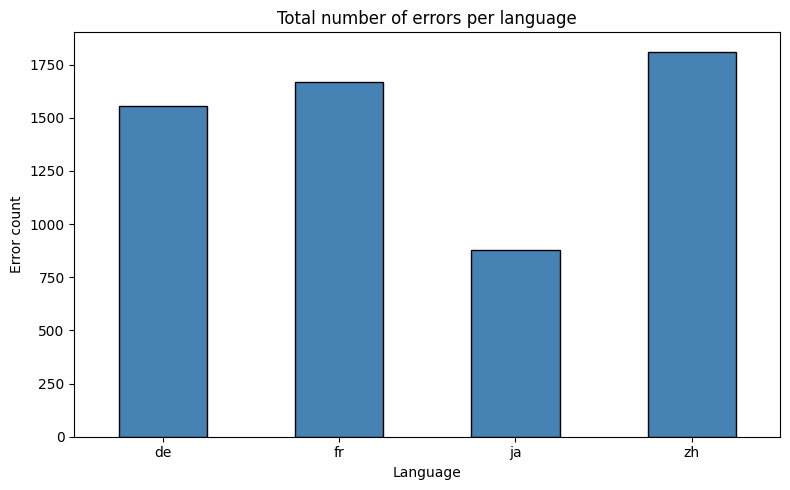

In [ ]:
import matplotlib.pyplot as plt

feature_cols = [col for col in test_error.columns if "feature" in col]

# sum all errors per language
errors_per_language = test_error.groupby("label")[feature_cols].sum().sum(axis=1)

errors_per_language.plot(kind="bar", figsize=(8, 5), color="steelblue", edgecolor="black")
plt.title("Total number of errors per language")
plt.xlabel("Language")
plt.ylabel("Error count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

We can see above that the error count is similar for Chinese, German and French native speakers, while number of errors aggregated among texts by Japanese speakers is lower. This might be again due to the fact that for Japanese, there are more texts in the B1 range than A2.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier



In [ ]:
feature_cols = [i for i in test_error.columns if "feature" in i ]
df_normalized = test_error.copy()

row_totals = test_error[feature_cols].sum(axis=1)

test_error[feature_cols] = test_error[feature_cols].div(row_totals, axis=0)

In [ ]:
labels_def = np.unique(test_error["label"])
mi_per_label = {}
features_check = [list(i["features"].keys()) for i in error_samples]

recap_results = {}
for k in labels_def:
    y_binary = (pd.Series(test_error["label"].to_list())== k).astype(int)
    print(k)
    res = mutual_info_classif(test_error[feature_cols].values, y_binary, discrete_features = "auto").tolist()
    res_dict = dict(zip(features_check[0], res))
    sorted_dict = dict(sorted(res_dict.items(), key=lambda item: item[1], reverse=True))
    mi_per_label[k] = sorted_dict
    print(sorted_dict)




de
{'CK0': 0.04551462447431631, 'Len1': 0.04303444991075356, 'MissChar': 0.04066168079931498, 'Quant0': 0.03442540108431569, 'Tail0': 0.02739820073284638, 'Cap0': 0.026230250750955975, 'Head0': 0.024541512648012853, 'CK1': 0.024197793160198433, 'Cap1': 0.02032266254030879, 'Caron1': 0.017584124142604685, 'Gemin0': 0.016437738797820067, 'EpentE1': 0.014893377680980535, 'Meta': 0.014633466269291295, 'YJ0': 0.012306459165551509, 'Y0': 0.012225936085922262, 'Gemin1': 0.009064340561037332, 'Caron0': 0.007332423512272035, 'RedunChar': 0.007245249807471321, 'Mne1': 0.002183790158228227, 'Quant1': 0.0, 'SingCh': 0.0, 'Unspec': 0.0, 'DiaE': 0.0, 'Voiced': 0.0, 'Y1': 0.0, 'Tail1': 0.0, 'Mne0': 0.0, 'Palat0': 0.0, 'ProtJ1': 0.0, 'VoicedFin0': 0.0, 'Voiced0': 0.0, 'Head1': 0.0, 'Head': 0.0, 'EpentE0': 0.0, 'Len0': 0.0, 'Pre1': 0.0, 'VoicedFin1': 0.0, 'DiaU': 0.0, 'Dtn': 0.0, 'Voiced1': 0.0}
fr
{'Quant0': 0.05206770083193302, 'YJ0': 0.040334017367189334, 'Y0': 0.036851652996216844, 'RedunChar': 0.0

According to the mutual information measure between the normalized frequency of errors within the error class and their respective labels, we can see that most error types do not have high enough mutual information, barely exceeding 0, except for Japanese. For this language, it seems that the Quant0 measure (which signifies the absence of a long vowel specifier in writing) is informative wrt to determining whether an example text was produced by a native Japanese speaker. However, no direct parallel can be made with Japanese phonology (since long / short vowel distinctions already exist in this language), so this could be either due to the different vowel phonemes or the difficulty of accounting for these differences in a new writing system. Based on these mutual information values, we select a set of features accross all languages, noting that even with small values, the ranking by MI is still different accross all these languages.

In [ ]:


error_samples = test_error
selected_features = ["Quant0", "SingCh", "Caron0",  "YJ0", "Y0", "Y1", "CK0", "Head", "Voiced0", "Unspec", "EpentE1", "Gemin1", "VoicedFin1", "MissChar", "RedunChar"]

filtered_samples = error_samples.drop(["features."+i for i in selected_features if i not in selected_features])
filtered_labels = filtered_samples["label"].to_list()

filtered_features = filtered_samples.drop(["text_id", "label"],axis=1)
features= filtered_features.values


In [ ]:
def train_svm_new(features, labels):
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.15, random_state=42, stratify=labels
    )
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", OneVsRestClassifier(RandomForestClassifier(max_depth = 2)))
    ])
    param_grid = {
    "clf__estimator__n_estimators": [100],
    "clf__estimator__max_depth": [None, 10],
    "clf__estimator__min_samples_split": [2],
    "clf__estimator__min_samples_leaf": [1, 2],
    "clf__estimator__max_features": ["log2"],
    "clf__estimator__class_weight": ["balanced", None],
}
    grid = GridSearchCV(pipe, param_grid,
                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                        scoring="f1_macro")
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)

    f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)

    print(f"Best params: {grid.best_params_}")
    print(f"F1 macro: {f1:.4f}")
    print("classification report")
    print(classification_report(y_test, y_pred, target_names=["de", "zh", "ja","fr"]))
    print("Confusion matrix:\n", cm)


    return grid, f1, cm


Best params: {'clf__estimator__class_weight': 'balanced', 'clf__estimator__max_depth': None, 'clf__estimator__max_features': 'log2', 'clf__estimator__min_samples_leaf': 1, 'clf__estimator__min_samples_split': 2, 'clf__estimator__n_estimators': 100}
F1 macro: 0.3876
classification report
              precision    recall  f1-score   support

          de       0.43      0.38      0.40        16
          zh       0.23      0.25      0.24        12
          ja       0.50      0.50      0.50        18
          fr       0.40      0.42      0.41        19

    accuracy                           0.40        65
   macro avg       0.39      0.39      0.39        65
weighted avg       0.40      0.40      0.40        65

Confusion matrix:
 [[6 3 2 5]
 [4 3 2 3]
 [2 3 9 4]
 [2 4 5 8]]


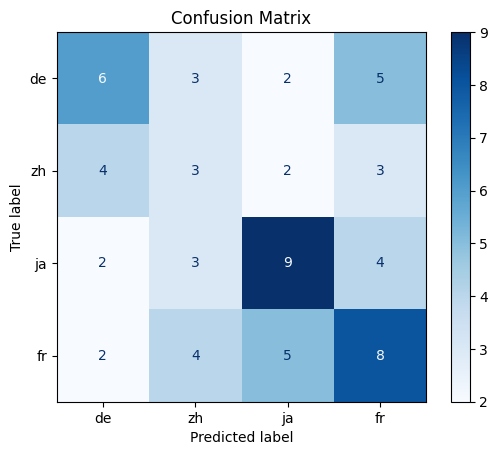

In [ ]:
estim,score, cm  = train_svm_new(features, filtered_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["de", "zh", "ja","fr"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



The confusion matrix shows that error frequency patterns of Japanese learners are easily capturable by the model, with the samples in the test set only being confused with French, which actually aligns with the MI values ranking we obtained. Despite this, the MI values are still too low to draw a relable conclusion. On the other hand, German and Chinese have the lowest accuracies, which also aligns with the fact that the features with the highest MIs have diverging patterns.
Overall, this shows that the present error annotations are not enough to distinguish between languages reliably, especially since running the model several times does maintain high rates of success for French/ Japanese, but does seem to have unreliable prediction patterns otherwise. We posit that this might be due to
1) different distributions accross language levels, which act as a confounder (this was explored before, training on level instead of L1 does not improve accuracy)
2) the annotations being somewhat redundant: indeed they are "flattened" because of the orthographic scope of the annotations (for instance, the annotators make a distinction when a learner writes down a long vowel as a short one, vs vice-versa, whereas this distinction might not matter as much if it doesn't exist in the learners native language/ if they are using a different alphabet).
Therefore, unifying some of the features/ testing on the newer corpora might yield better results.

N-Gram classification

In this section, we will first look at Information Gain (or mutual information) in regards to the label, to see how this varies accross datasets. The aim is to compare this with the vocab (or n-gram feature size) in order to see whether we can derive conclusions about what makes it hard to work with a particular corpus/ why predictions are more successful for BAWE as we are about to see.

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopwords_english = set(stopwords.words('english'))

In [ ]:
!pip install stop-words -q
from stop_words import get_stop_words
czech_stopwords = get_stop_words("cs")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
print(czech_stopwords)

['a', 'aby', 'ačkoli', 'ahoj', 'aj', 'ale', 'anebo', 'ani', 'aniž', 'ano', 'asi', 'aspoň', 'az', 'až', 'během', 'bez', 'beze', 'blízko', 'bohužel', 'brzo', 'bude', 'budem', 'budeme', 'budes', 'budeš', 'budete', 'budou', 'budu', 'by', 'byl', 'byla', 'byli', 'bylo', 'byly', 'bys', 'byt', 'být', 'ci', 'clanek', 'clanku', 'clanky', 'co', 'coz', 'což', 'cz', 'čau', 'či', 'článek', 'článku', 'články', 'čtrnáct', 'čtyři', 'dál', 'dále', 'daleko', 'dalsi', 'další', 'děkovat', 'děkujeme', 'děkuji', 'den', 'deset', 'design', 'devatenáct', 'devět', 'dnes', 'do', 'dobrý', 'docela', 'dva', 'dvacet', 'dvanáct', 'dvě', 'email', 'ho', 'hodně', 'chce', 'chceme', 'chceš', 'chcete', 'chci', 'chtějí', 'chtít', "chut'", 'chuti', 'i', 'já', 'jak', 'jako', 'jde', 'je', 'jeden', 'jedenáct', 'jedna', 'jedno', 'jednou', 'jedou', 'jeho', 'jej', 'jeji', 'její', 'jejich', 'jemu', 'jen', 'jenom', 'jenž', 'jeste', 'jestli', 'jestliže', 'ještě', 'ji', 'jí', 'jich', 'jím', 'jimi', 'jinak', 'jine', 'jiné', 'jiz', 'již'

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

def compute_information_gain(vectorizer, X_train, y_train):
    feature_names = vectorizer.get_feature_names_out()

    ig_scores = mutual_info_classif(X_train, y_train, discrete_features=True, random_state=42)

    ig_df = pd.DataFrame({
        "feature": feature_names,
        "information_gain": ig_scores
    }).sort_values("information_gain", ascending=False).reset_index(drop=True)

    return ig_df

X_train, X_test, y_train, y_test = train_test_split(
    bawe_dataset["sentences"],
    bawe_dataset["labels"],
    test_size=0.15,
    stratify=bawe_dataset["labels"]
)

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train)
ig_df = compute_information_gain(vectorizer, X_train, y_train)
#print(ig_df.head(20))

Information Gain: BAWE token n-grams (no stop words)

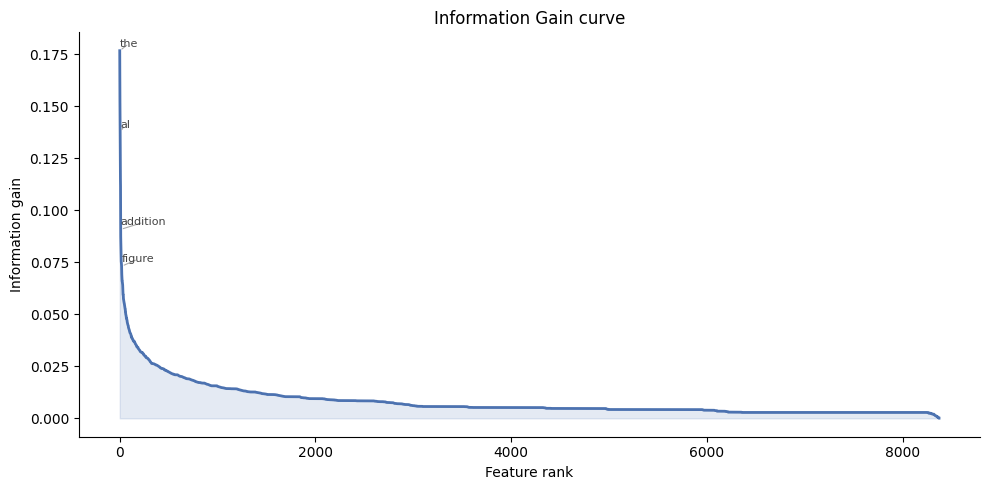

In [ ]:
def plot_ig_curve(ig_df, title="Information Gain curve", n_top=9000):
    """
    Plots the IG scores as a ranked curve to show how quickly
    informativeness drops off across features.
    """
    ig_sorted = ig_df.head(n_top).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(ig_sorted.index, ig_sorted["information_gain"],
            color=PALETTE[0], linewidth=2)
    ax.fill_between(ig_sorted.index, ig_sorted["information_gain"],
                    alpha=0.15, color=PALETTE[0])

    # Annotate a few landmark features
    for i in [0, 4, 9, 19, n_top - 1]:
        if i < len(ig_sorted):
            ax.annotate(
                ig_sorted.loc[i, "feature"],
                xy=(i, ig_sorted.loc[i, "information_gain"]),
                xytext=(i + 0.5, ig_sorted.loc[i, "information_gain"] + 0.002),
                fontsize=8, color="#444",
                arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8)
            )

    ax.set_xlabel("Feature rank")
    ax.set_ylabel("Information gain")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_ig_curve(ig_df)

As seen above, words which seem high frequency seem to present the most information gain out of the unigram vocab.

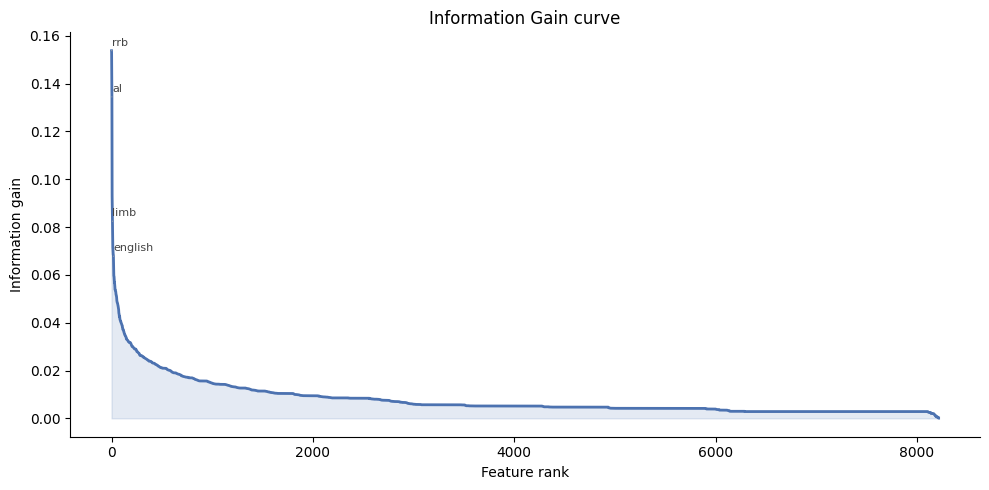

In [ ]:
X_train_eng, X_test, y_train, y_test = train_test_split(
    bawe_dataset["sentences"],
    bawe_dataset["labels"],
    test_size=0.15,
    stratify=bawe_dataset["labels"]
)

vectorizer = CountVectorizer(stop_words = list(stopwords_english))
X_train_eng = vectorizer.fit_transform(X_train_eng)
ig_df = compute_information_gain(vectorizer, X_train_eng, y_train)
plot_ig_curve(ig_df)

Plotting the information gain per n-gram feature while exlcuding the stop words from the vocab does not reveal much else, since high frequency items seem to dominate the distribution again (e.g "al" from referencing, which is a staple of academic writing). However, a possible effect of topic is to be seen here, where "english" likely comes from linguistics essays (remember that we have two available categories)

Information gain: Unigrams on the CzESL dataset

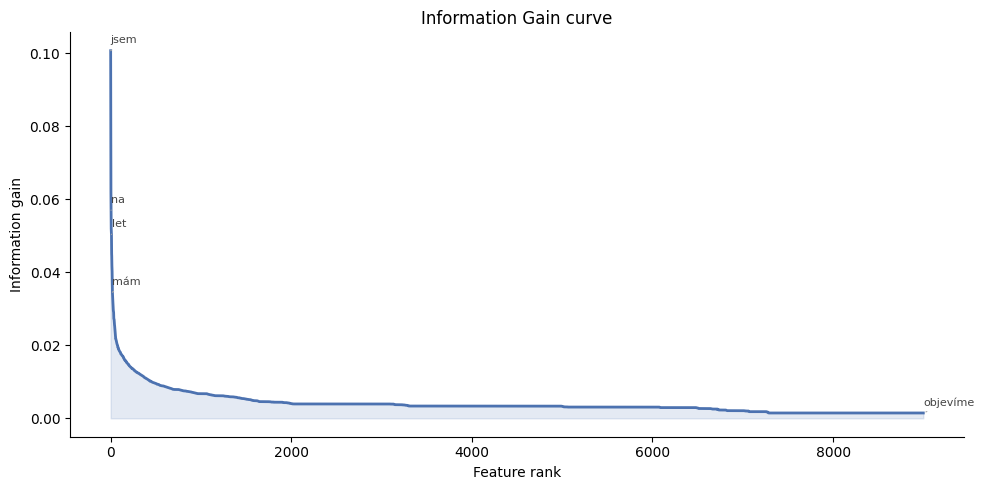

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    czech_df["sentences"],
    czech_df["labels"],
    test_size=0.15,
    stratify=czech_df["labels"]
)

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train)
ig_df = compute_information_gain(vectorizer, X_train, y_train)
plot_ig_curve(ig_df)

Similarly to the English dataset, most of the mutual information between individual n-gram features and labels is concentrated around high-frequency words

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['chut', 'ted'] not in stop_words.
  warnings.warn(


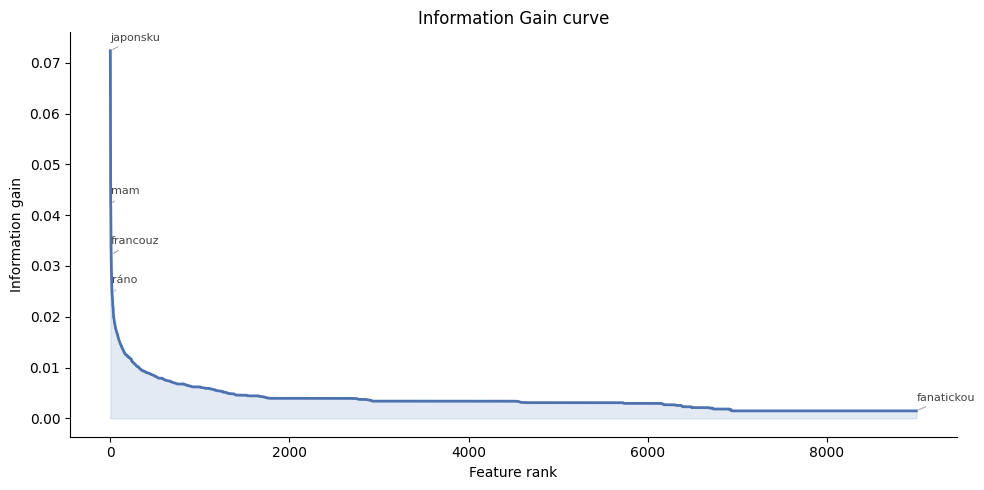

In [ ]:
X_train_cz, X_test, y_train, y_test = train_test_split(
    czech_df["sentences"],
    czech_df["labels"],
    test_size=0.15,
    stratify=czech_df["labels"]
)

vectorizer = CountVectorizer(stop_words = list(czech_stopwords))
X_train_cz = vectorizer.fit_transform(X_train_cz)
ig_df = compute_information_gain(vectorizer, X_train_cz, y_train)
plot_ig_curve(ig_df)

In [ ]:
# Comparing vector size
print(X_train_eng.shape)
print(X_train_cz.shape)



(340, 8217)
(508, 10577)


After removing the stopwords in the BAWE dataset, we can observe that in constrast with the CzESL dataset, there remain more features that are informative wrt to the label. The most informative unigram for Czech is actually "japonsku", followed by "francouz" which shows that the topic might have an impact on classification even in low proficiency settings. What is interesting is that there are actually more unigram features available for Czech than for English (despite the tokenization scheme working with white space. Mispellings would be one factor explaining the high number of features despite the low proficiency setting).

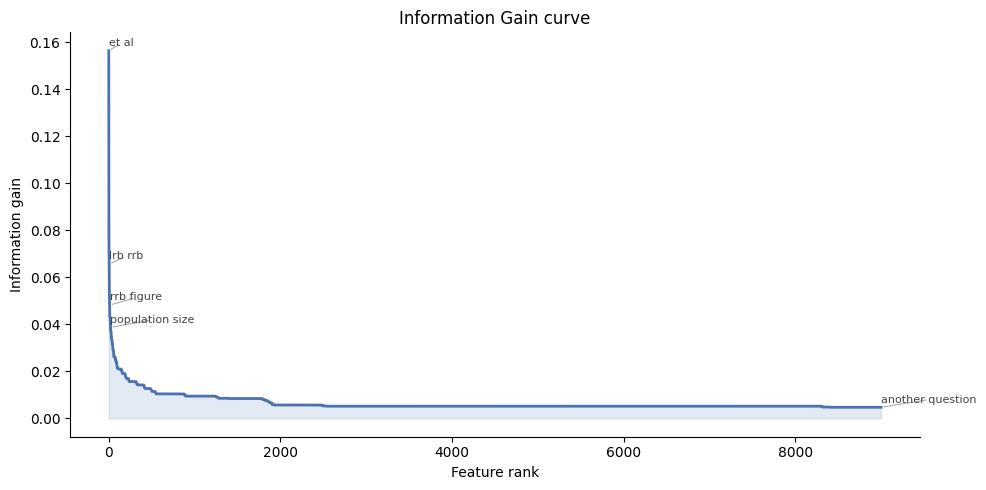

In [ ]:
X_train_eng, X_test, y_train, y_test = train_test_split(
    bawe_dataset["sentences"],
    bawe_dataset["labels"],
    test_size=0.15,
    stratify=bawe_dataset["labels"]
)

vectorizer = CountVectorizer(ngram_range = (2,2), stop_words = list(stopwords_english))
X_train_eng = vectorizer.fit_transform(X_train_eng)
ig_df = compute_information_gain(vectorizer, X_train_eng, y_train)
plot_ig_curve(ig_df)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['chut', 'ted'] not in stop_words.
  warnings.warn(


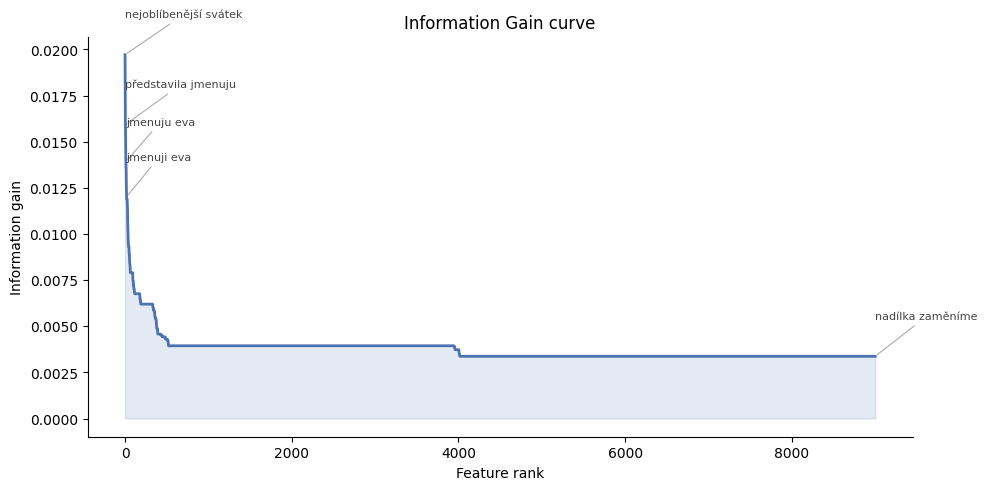

In [ ]:
X_train_cz, X_test, y_train, y_test = train_test_split(
    czech_df["sentences"],
    czech_df["labels"],
    test_size=0.15,
    stratify=czech_df["labels"]
)

vectorizer = CountVectorizer(ngram_range = (2,2),stop_words= list(czech_stopwords))
X_train_cz = vectorizer.fit_transform(X_train_cz)
ig_df = compute_information_gain(vectorizer, X_train_cz, y_train)
plot_ig_curve(ig_df)

In [ ]:
print(X_train_cz.shape)
print(X_train_eng.shape)

(340, 9239)
(340, 39042)


For the bigram analysis, it looks like the BAWE bigrams reflect high frequency words again, while for the BAWE one, the native language bias is not so visible anymore, indicating there are potentially features beyond topic words that are relatable with the native language labels

The bigram analysis reveals that bigrams are actually less informative for the BAWE corpus. This is potentially an effect of the level of speech, but is also derived from the larger number of bigrams available for English, as opposed to Czech

Keeping these results in mind, we hypothesize that the performance on bigrams will be higher than for unigrams when looking at word n-grams + stopwords. Note that in the future, to examine the differences between MI distribution between n-gram features, it might be interesting to pick a threshold at which we obtain the area under the curve, in order to be able to quantify those differences better.  

Training SVMs model with N-Grams

Looking at the MI as above informed us of the potential limitations/ performances of our datasets, and what might influence the predictions for each type of data (we for instance expect unigrams feature to perform better on the CzESL dataset). Keeping in mind limitations like topic bias, we now train SVM models on each dataset with different hyperparameters / kernel types on the following features:

1)  Word tokens

    1a) Word tokens without stop words

    1b) Word tokens without stop words + TF-IDF weighing

2) POS tokens

3) Dependency relations

For each type of feature, we record the F1-score for unigram, bigram and trigrams, and test out different parameters using GridSearchCV before selecting the best performing model.

The goal is to see how the best features differ for each language / dataset, and we discuss whether this has to do with proficiency level / topic.

In [ ]:
parameter_grid = {
    "estimator__C": [1, 10, 100],
    "estimator__kernel": ["linear", "poly", "rbf"],
    "estimator__gamma": ["scale", "auto", 0.001, 0.01]
}

ngram_ranges = {"unigram": (1, 1), "bigram": (2, 2), "trigram": (3, 3)}


class NGramAnalyzer:
    def __init__(self, dataset, stopwords=False, dataset_label="BAWE", avg=["weighted"]):
        self.dataset_label = dataset_label
        self.dataset = dataset
        self.stopwords = {"czech": czech_stopwords, "english": stopwords_english}
        self.ngram_ranges = ngram_ranges
        self.label_encoder = LabelEncoder()
        self.labels = self.dataset["labels"]
        self.encoded_labels = self.label_encoder.fit_transform(self.labels)
        self.count_vectorizer = CountVectorizer()
        self.tfidf_vectorizer = TfidfVectorizer()
        self.metrics = avg
        self.baseline_model = DummyClassifier(strategy="most_frequent")

    def get_best_overall(self, results_by_ngram):
        best_label = max(
            results_by_ngram,
            key=lambda k: results_by_ngram[k]["results"]["scores"]["f1_macro"]
        )
        best = results_by_ngram[best_label]
        print(f"\nBest ngram range: {best_label}")
        print(f"F1 macro: {best['results']['scores']['f1_macro']:.4f}")
        print(f"Best params: {best['results']['best_params']}")
        return best_label, best

    def ngram_analysis(self, use_tfidf=False, text_field="sentences", stopwords=False):
        results_by_ngram = dict()
        baseline_results = dict()
        output_name = self.dataset_label

        for label in self.ngram_ranges.keys():
            ngram = self.ngram_ranges[label]
            self.count_vectorizer.n_gram_range = ngram

            if stopwords:
                if "BAWE" in self.dataset_label:
                    self.count_vectorizer.stop_words = list(self.stopwords["english"])
                else:
                    self.count_vectorizer.stop_words = list(self.stopwords["czech"])

            if use_tfidf:
                vectorized_data = self.tfidf_vectorizer.fit_transform(self.dataset[text_field])
                output_name += "_tfidf_"
            else:
                vectorized_data = self.count_vectorizer.fit_transform(self.dataset[text_field])

            X_train, X_test, y_train, y_test = train_test_split(
                vectorized_data,
                self.labels,
                test_size=0.15,
                stratify=self.labels
            )

            self.baseline_model.fit(X_train, y_train)
            baseline_preds = self.baseline_model.predict(X_test)
            baseline_results[label] = f1_score(y_test, baseline_preds, average="macro")

            wrapped_model = OneVsRestClassifier(estimator=SVC())
            metric_results = dict()

            grid_search = GridSearchCV(
                wrapped_model,
                param_grid=parameter_grid,
                scoring="f1_macro"
            ).fit(X_train, y_train)

            best_model = grid_search.best_estimator_
            print(f"[{label}] best estimator: {best_model}")

            predictions = best_model.predict(X_test)

            metric_results["results"] = {
                "confusion_matrix": confusion_matrix(
                    y_test,
                    predictions,
                    labels=list(set(self.labels))
                ),
                "scores": {
                    "f1_micro": f1_score(y_test, predictions, average="micro"),
                    "f1_macro": f1_score(y_test, predictions, average="macro"),
                    "f1_weighted": f1_score(y_test, predictions, average="weighted")
                },
                "best_params": grid_search.best_params_,
                "best_model": best_model
            }

            score = classification_report(y_test, predictions, target_names=list(set(self.labels)))
            print("score")
            print(score)

            results_by_ngram[label] = metric_results

        return results_by_ngram
    def plot_scores(self, results_by_ngram, title=None):
      metrics = ["f1_micro", "f1_macro", "f1_weighted"]
      ngram_labels = list(results_by_ngram.keys())
      x = np.arange(len(ngram_labels))
      width = 0.25

      fig, ax = plt.subplots(figsize=(9, 5))

      for i, metric in enumerate(metrics):
          scores = [results_by_ngram[k]["results"]["scores"][metric] for k in ngram_labels]
          bars = ax.bar(x + i * width, scores, width, label=metric, color=PALETTE[i])
          for bar, score in zip(bars, scores):
              ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{score:.2f}", ha="center", fontsize=8, color="#444")

      ax.set_xticks(x + width)
      ax.set_xticklabels(ngram_labels)
      ax.set_ylim(0, 1.05)
      ax.set_ylabel("Score")
      ax.set_title(title or f"{self.dataset_label} — N-gram classification scores")
      ax.legend()
      ax.spines[["top", "right"]].set_visible(False)
      plt.tight_layout()
      plt.show()




Token N-grams without stopwords and with standard vectorization

[unigram] best estimator: OneVsRestClassifier(estimator=SVC(C=100, gamma='auto'))
score
                  precision    recall  f1-score   support

        Japanese       1.00      0.73      0.85        15
          German       0.79      0.73      0.76        15
Chinese Mandarin       0.68      0.87      0.76        15
          French       0.75      0.80      0.77        15

        accuracy                           0.78        60
       macro avg       0.80      0.78      0.79        60
    weighted avg       0.80      0.78      0.79        60

[bigram] best estimator: OneVsRestClassifier(estimator=SVC(C=100, gamma='auto'))
score
                  precision    recall  f1-score   support

        Japanese       0.78      0.93      0.85        15
          German       0.67      0.67      0.67        15
Chinese Mandarin       0.75      0.80      0.77        15
          French       1.00      0.73      0.85        15

        accuracy                           0.78        60
       m

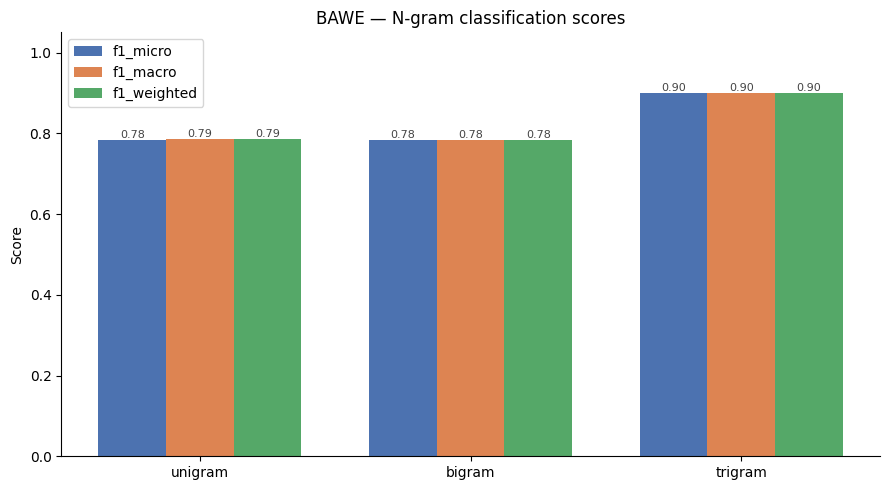

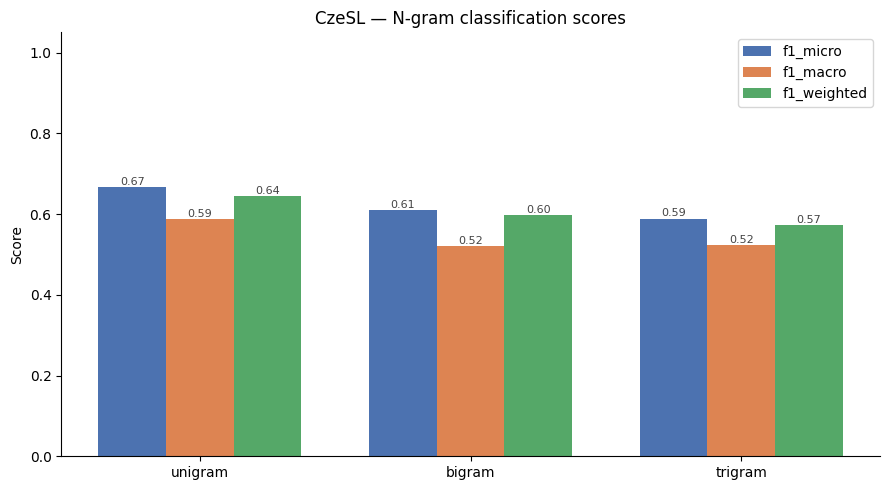

In [ ]:
analyzer_bawe = NGramAnalyzer(sample_bawe, dataset_label="BAWE")
results_bawe = analyzer_bawe.ngram_analysis()
print("Best performing model for BAWE corpus (word n-grams)")
best_label_bawe, best_bawe = analyzer_bawe.get_best_overall(results_bawe)
best_model_text_ngrams_eng = best_bawe["results"]["best_model"]
best_params_bawe = best_bawe["results"]["best_params"]

analyzer_cze = NGramAnalyzer(czech_df, dataset_label="CzeSL")
results_cze = analyzer_cze.ngram_analysis()
print("Best performing model for CzeSL corpus (word n-grams)")
best_label_cze, best_cze = analyzer_cze.get_best_overall(results_cze)
best_model_text_ngrams_cze = best_cze["results"]["best_model"]
best_params_cze = best_cze["results"]["best_params"]


analyzer_bawe.plot_scores(results_bawe)
analyzer_cze.plot_scores(results_cze)

For the token n-gram (keeping the stopwords), our results somewhat align with what we observed when looking at the information gain of features. For the CzESL dataset, the best performing model actually employs unigram features, whereas on the BAWE dataset, unigram and bigram performance are similar in the broader sense (with a dip in recall for the model trained on bigrams), while the best F1-scores are obtained through the trigram data.
This is consistent with what we obtained with the information gain metric, which predicted slightly worse performance on the bigram model for BAWE, and higher performance with unigrams on CzESL, which also suggests that for the Czech dataset, native language can be predicted from individual words which could simply refer to the place of origin of the speaker (e.g "japonsku" showing the elevated MI for the unigram model)

In [ ]:

print(best_params_cze)
print(best_params_bawe)
print(best_label_bawe)
print(best_label_cze)

OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001))
OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='poly'))
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'rbf'}
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'poly'}
unigram
trigram


[unigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
score
                  precision    recall  f1-score   support

        Japanese       1.00      0.80      0.89        15
          German       0.75      0.80      0.77        15
Chinese Mandarin       0.80      0.80      0.80        15
          French       0.88      1.00      0.94        15

        accuracy                           0.85        60
       macro avg       0.86      0.85      0.85        60
    weighted avg       0.86      0.85      0.85        60

[bigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
score
                  precision    recall  f1-score   support

        Japanese       1.00      0.87      0.93        15
          German       0.88      1.00      0.94        15
Chinese Mandarin       0.92      0.80      0.86        15
          French       0.88      1.00      0.94        15

        accuracy                    

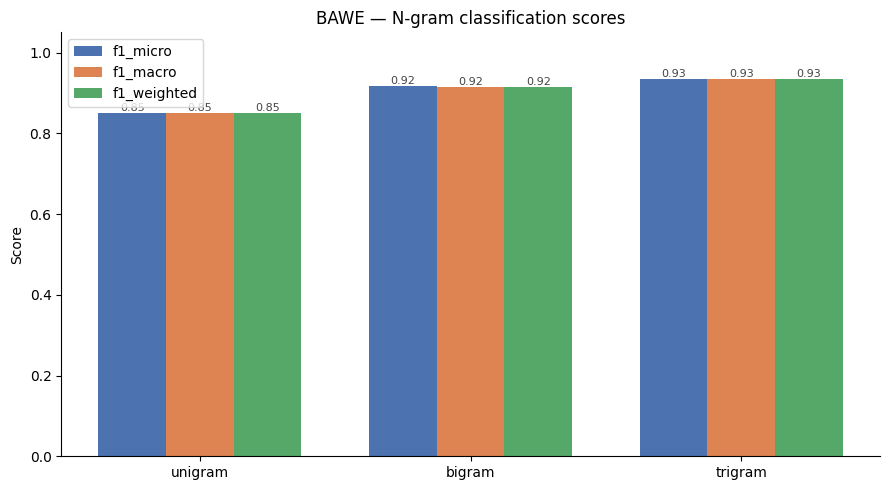

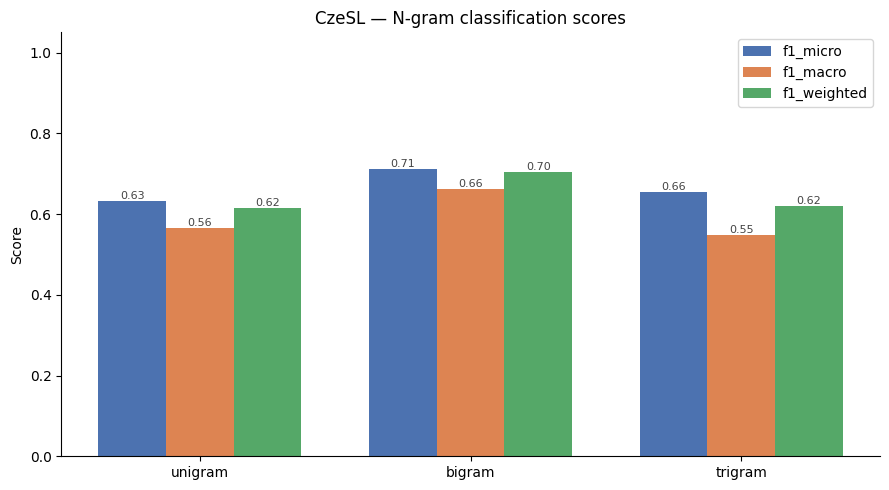

In [ ]:
analyzer_bawe = NGramAnalyzer(bawe_dataset, dataset_label="BAWE")
results_bawe = analyzer_bawe.ngram_analysis(use_tfidf = True)
print("Best performing model for BAWE corpus (word n-grams)w/ TF-IDF")
best_label_bawe, best_bawe = analyzer_bawe.get_best_overall(results_bawe)
best_model_text_ngrams_eng = best_bawe["results"]["best_model"]
best_params_bawe = best_bawe["results"]["best_params"]

analyzer_cze = NGramAnalyzer(czech_df, dataset_label="CzeSL")
results_cze = analyzer_cze.ngram_analysis(use_tfidf = True)
print("Best performing model for CzeSL corpus (word n-grams) w/ TF-IDF")
best_label_cze, best_cze = analyzer_cze.get_best_overall(results_cze)
best_model_text_ngrams_cze = best_cze["results"]["best_model"]
best_params_cze = best_cze["results"]["best_params"]


analyzer_bawe.plot_scores(results_bawe)
analyzer_cze.plot_scores(results_cze)

Switching the vectorizer to TF-IDF improves the performance for the SVMs trained on BAWE, while degrading F1-scores for the CzESL unigrams (but we observe an increase in the other n-gram configurations). Note that the new representations also induces the preferred kernel to change: the data becomes linearly separable again at the n-gram level (whereas a rbf kernel was needed before). The best predictor configurations in terms of n-grams stays the same with this feature scheme: bigram for CzESL and trigram for BAWE.

In [ ]:
print(best_model_text_ngrams_cze)
print(best_model_text_ngrams_eng)
print(best_params_cze)
print(best_params_bawe)
print(best_label_bawe)
print(best_label_cze)

OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'linear'}
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'linear'}
trigram
bigram


[unigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, kernel='linear'))
score
                  precision    recall  f1-score   support

          German       1.00      1.00      1.00        12
Chinese Mandarin       1.00      0.90      0.95        10
        Japanese       0.96      1.00      0.98        23
          French       1.00      1.00      1.00        15

        accuracy                           0.98        60
       macro avg       0.99      0.97      0.98        60
    weighted avg       0.98      0.98      0.98        60

[bigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, kernel='linear'))
score
                  precision    recall  f1-score   support

          German       1.00      1.00      1.00        12
Chinese Mandarin       1.00      0.90      0.95        10
        Japanese       0.92      1.00      0.96        23
          French       1.00      0.93      0.97        15

        accuracy                           0.97        60
    

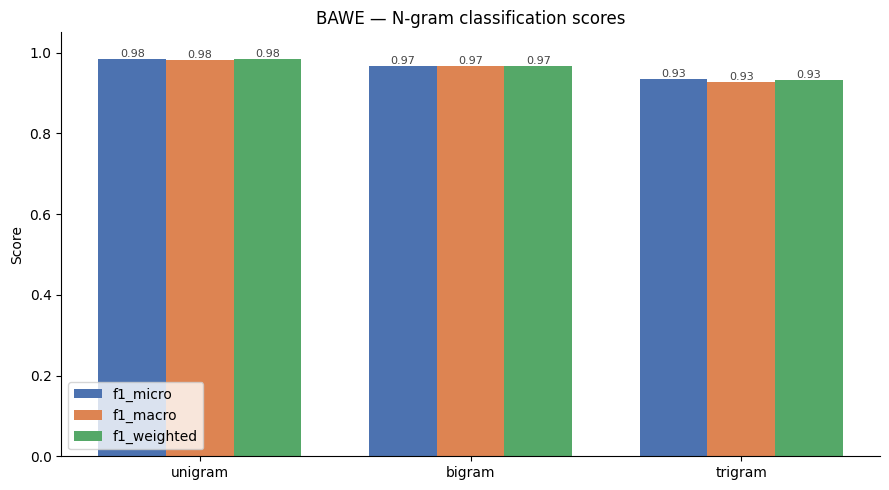

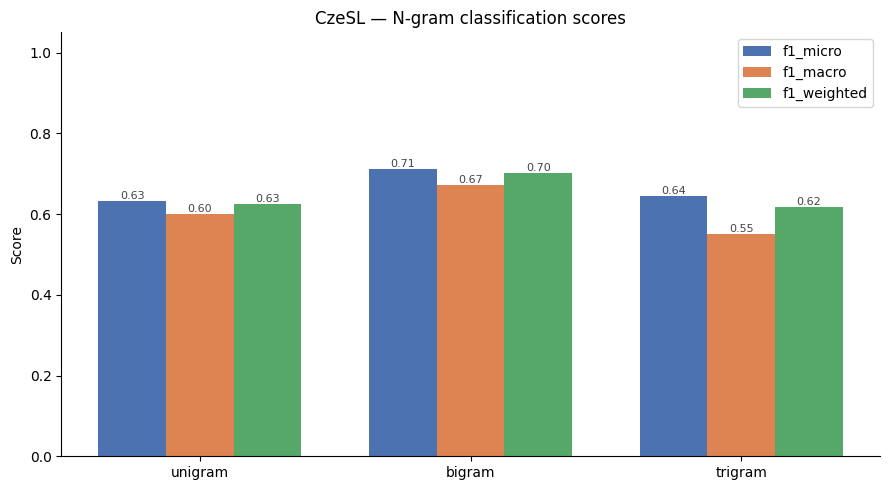

In [ ]:
analyzer_bawe = NGramAnalyzer(bawe_dataset, dataset_label="BAWE")
results_bawe = analyzer_bawe.ngram_analysis(stopwords= True, use_tfidf = True)
print("Best performing model for BAWE corpus (word n-grams)w/ TF-IDF and stopwords")
best_label_bawe, best_bawe = analyzer_bawe.get_best_overall(results_bawe)
best_model_text_ngrams_eng = best_bawe["results"]["best_model"]
best_params_bawe = best_bawe["results"]["best_params"]

analyzer_cze = NGramAnalyzer(czech_df, dataset_label="CzeSL")
results_cze = analyzer_cze.ngram_analysis(stopwords = True, use_tfidf = True)
print("Best performing model for CzeSL corpus (word n-grams) w/ TF-IDF and stopwords")
best_label_cze, best_cze = analyzer_cze.get_best_overall(results_cze)
best_model_text_ngrams_cze = best_cze["results"]["best_model"]
best_params_cze = best_cze["results"]["best_params"]


analyzer_bawe.plot_scores(results_bawe)
analyzer_cze.plot_scores(results_cze)

With the TF-IDF + no stopwords method, we actually obtain our best results. The best performing model fot BAWE is actually a unigram, vs a bigram again for CzESL, reversing the trend of the previous models where BAWE actually had trigrams as the best performing configuration.
On one hand, the fact that bigrams consistently work well with CzESL could mean that morphosyntactic features are the main factor distinguishing between languages. This stays the same accross all lexical item-based classifiers. Forr BAWE however, the reversal could indicate that when the n-gram vocab is bigger, differences lie in the phrasal structure, since the most of the information gain comes from high frequency tokens. However, if we stripe down these tokens, it seems that the differences appears mostly in individual word choice. But since it seems less likely to happend at a higher proficiency level, we would need to do some investigating in the future to determine if this is due to the bias in the distribution of the essay topics or actual linguistic differences.

POS N-grams: Note
The POS annotations schemes differ for BAWE (which uses the Penn Tree Bank set of tags) and CzESL (uses the UD tagging set). Therefore, in order to be able to compare performance accross the two languages, we use the tagset mapping specified on the [UD website](https://universaldependencies.org/tagset-conversion/en-penn-uposf.html). Since this requires some adjustments, it might actually not be a perfect one to one mapping.

In [ ]:
import stanza

stanza.download("en")
nlp_stanza = stanza.Pipeline("en", processors="tokenize,pos")

def get_upos_sequence(text):
    doc = nlp_stanza(text)
    return " ".join(word.upos for sent in doc.sentences for word in sent.words)

sample_bawe["upos"] = sample_bawe["sentences"].apply(get_upos_sequence)

INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.12.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor | Package         |
-------------------------------
| tokenize  | combined        |
| mwt       | combined        |
| pos       | combined_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!


[unigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001))
score
                  precision    recall  f1-score   support

Chinese Mandarin       0.39      0.80      0.52        15
        Japanese       0.50      0.47      0.48        15
          French       0.50      0.07      0.12        15
          German       0.38      0.33      0.36        15

        accuracy                           0.42        60
       macro avg       0.44      0.42      0.37        60
    weighted avg       0.44      0.42      0.37        60

[bigram] best estimator: OneVsRestClassifier(estimator=SVC(C=1, gamma=0.001, kernel='poly'))
score
                  precision    recall  f1-score   support

Chinese Mandarin       0.22      0.13      0.17        15
        Japanese       0.41      0.60      0.49        15
          French       0.00      0.00      0.00        15
          German       0.38      0.40      0.39        15

        accuracy                           0.28        6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[trigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
score
              precision    recall  f1-score   support

      French       0.56      0.95      0.71        43
      German       0.33      0.17      0.22        12
    Japanese       0.00      0.00      0.00        16
     Chinese       0.44      0.21      0.29        19

    accuracy                           0.52        90
   macro avg       0.33      0.33      0.30        90
weighted avg       0.41      0.52      0.43        90

Best performing model for CzeSL corpus (POS n-grams) w/ TF-IDF and stopwords

Best ngram range: bigram
F1 macro: 0.3680
Best params: {'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'linear'}


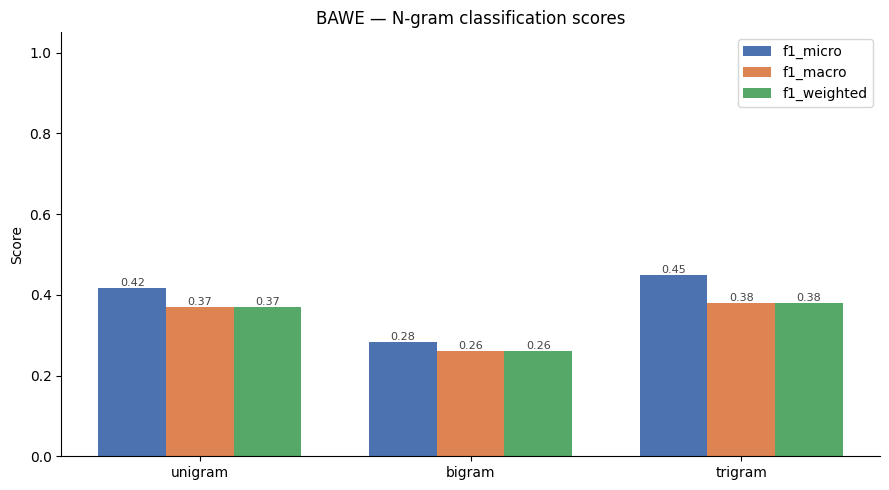

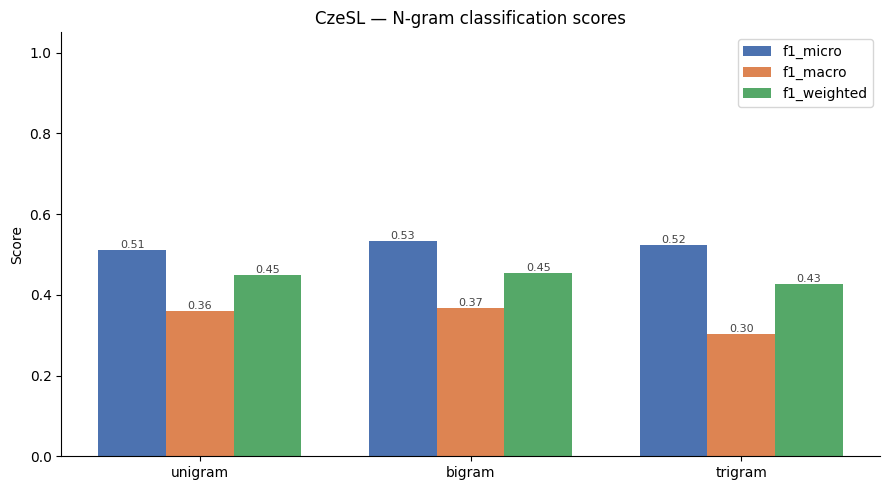

In [ ]:
analyzer_bawe = NGramAnalyzer(sample_bawe, dataset_label="BAWE")
results_bawe = analyzer_bawe.ngram_analysis(use_tfidf = True,text_field = "upos")
print("Best performing model for BAWE corpus (POS n-grams)")
best_label_bawe, best_bawe = analyzer_bawe.get_best_overall(results_bawe)
best_model_text_ngrams_eng = best_bawe["results"]["best_model"]
best_params_bawe = best_bawe["results"]["best_params"]

analyzer_cze = NGramAnalyzer(czech_df, dataset_label="CzeSL")
results_cze = analyzer_cze.ngram_analysis(use_tfidf = True, text_field = "upos")
print("Best performing model for CzeSL corpus (POS n-grams) w/ TF-IDF and stopwords")
best_label_cze, best_cze = analyzer_cze.get_best_overall(results_cze)
best_model_text_ngrams_cze = best_cze["results"]["best_model"]
best_params_cze = best_cze["results"]["best_params"]


analyzer_bawe.plot_scores(results_bawe)
analyzer_cze.plot_scores(results_cze)

UPOS n-grams show better performance on the CzESL dataset vs BAWE. This either points to the fact that morpho syntactic features are more varied in the CzESL errors because of transfer effects (and therefore indicates that learners of Czech as a second language are making errors/ using constructions from their native language), or perhaps just reflects the freer word order in Czech.

In [ ]:
# Same estimators
print(best_model_text_ngrams_cze)
print(best_model_text_ngrams_eng)
print(best_params_cze)
print(best_params_bawe)
print(best_label_bawe)
print(best_label_cze)

OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001))
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'linear'}
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'rbf'}
trigram
bigram


[unigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
score
                  precision    recall  f1-score   support

Chinese Mandarin       0.67      0.13      0.22        15
        Japanese       0.46      0.87      0.60        15
          French       0.70      0.47      0.56        15
          German       0.47      0.60      0.53        15

        accuracy                           0.52        60
       macro avg       0.58      0.52      0.48        60
    weighted avg       0.58      0.52      0.48        60

[bigram] best estimator: OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
score
                  precision    recall  f1-score   support

Chinese Mandarin       0.43      0.20      0.27        15
        Japanese       0.46      0.73      0.56        15
          French       0.44      0.27      0.33        15
          German       0.45      0.60      0.51        15

        accuracy                    

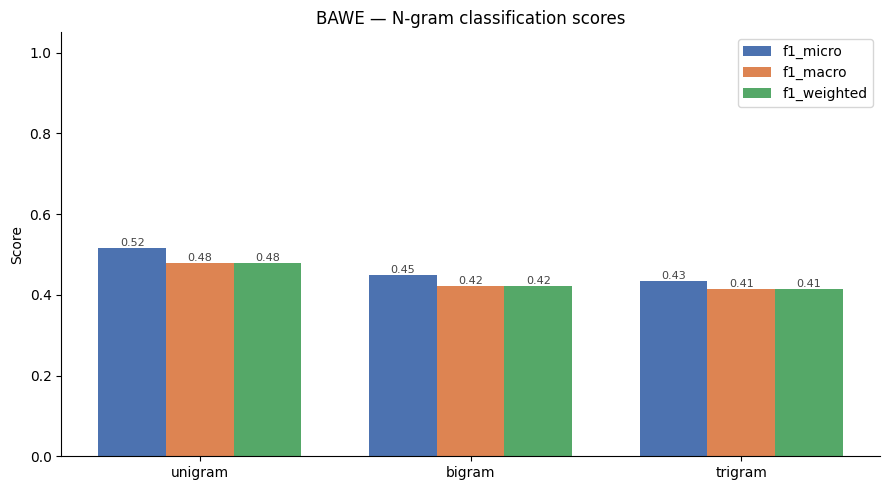

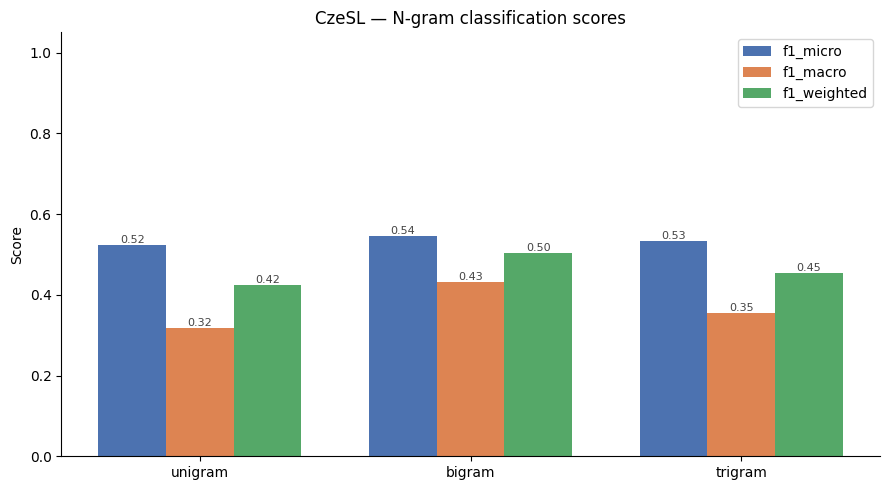

In [ ]:
analyzer_bawe = NGramAnalyzer(sample_bawe, dataset_label="BAWE")
results_bawe = analyzer_bawe.ngram_analysis(use_tfidf = True,text_field = "dep")
print("Best performing model for BAWE corpus (POS n-grams)")
best_label_bawe, best_bawe = analyzer_bawe.get_best_overall(results_bawe)
best_model_text_ngrams_eng = best_bawe["results"]["best_model"]
best_params_bawe = best_bawe["results"]["best_params"]

analyzer_cze = NGramAnalyzer(czech_df, dataset_label="CzeSL")
results_cze = analyzer_cze.ngram_analysis(use_tfidf = True, text_field = "dep")
print("Best performing model for CzeSL corpus (dependency n-grams) ")
best_label_cze, best_cze = analyzer_cze.get_best_overall(results_cze)
best_model_text_ngrams_cze = best_cze["results"]["best_model"]
best_params_cze = best_cze["results"]["best_params"]


analyzer_bawe.plot_scores(results_bawe)
analyzer_cze.plot_scores(results_cze)

In [ ]:
# Same estimators
print(best_model_text_ngrams_cze)
print(best_model_text_ngrams_eng)
print(best_params_cze)
print(best_params_bawe)
print(best_label_bawe)
print(best_label_cze)

OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
OneVsRestClassifier(estimator=SVC(C=10, gamma=0.001, kernel='linear'))
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'linear'}
{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'linear'}
unigram
bigram


Weisfeiler Lehman Graph Kernel

Next, we will try to use more abstract linguistic features by using the UD graphs we pre-processed earlier (obtaining collections of heads and nodes).
This was initially planned as an attempt to use the HDAG kernel [described here](https://proceedings.neurips.cc/paper/2003/hash/f7ac67a9aa8d255282de7d11391e1b69-Abstract.html), which was specifically designed for representing and classifying UD. Due to the ready availability of already implemented graph kernels, we opt for the Weisfeiler Lehman kernel instead, which takes into account node labels in additional to the graph structure, and has been used for document classification [before](https://github.com/ysig/GraKeL/blob/master/tutorials/text_categorization/text_categorization.ipynb).
The goal is to see whether a measure which does not rely on lexical frequency, but instead on the presence of given structures can actually help with NLI.

In [ ]:
!pip install grakel -q


Fixing Grakel: Grakel is not actively maintained and therefore suffers from compatibility issues (mostly with ongoing numpy releases that need to be patched). In the most current version, we actually only need to
1) suppress the ComplexWarning from an older version of Numpy
2) change the datatype in the vertexhistogram code

In [ ]:
import os
grakel_base = "/usr/local/lib/python3.12/dist-packages/grakel/kernels/"

patches = {
    "vertex_histogram.py": ('dtype=">f8"', 'dtype="float64"'),
    "random_walk.py": ("from numpy import ComplexWarning", "from numpy.exceptions import ComplexWarning"),
}

for filename, (old, new) in patches.items():
    path = os.path.join(grakel_base, filename)
    with open(path, "r") as f:
        content = f.read()
    with open(path, "w") as f:
        f.write(content.replace(old, new))

import grakel

In [ ]:
from sklearn.utils import Bunch

from grakel.kernels import WeisfeilerLehman, VertexHistogram
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


param_grid = {
    "estimator__C": [1, 10, 100, 1000],
    "estimator__gamma": [0.001, 0.0001],
    "estimator__degree": [1, 2, 3, 4]
}

metrics = ["accuracy", "precision", "recall", "f1_score"]

graph_kernel = WeisfeilerLehman(
    n_iter=4,
    base_graph_kernel=VertexHistogram,
    normalize=True
)

dummy_classifier = DummyClassifier(strategy="most_frequent")


def weisfeiler_lehman_svm(data, dataset_name):
    train_graphs, test_graphs, train_labels, test_labels = train_test_split(
        data.data,
        data.target,
        test_size=0.1,
        random_state=42
    )

    train_kernel = graph_kernel.fit_transform(train_graphs)
    test_kernel = graph_kernel.transform(test_graphs)

    baseline_scores = []

    dummy_classifier.fit(train_graphs, train_labels)
    baseline_predictions = dummy_classifier.predict(test_kernel)

    baseline_accuracy = round(
        accuracy_score(test_labels, baseline_predictions), 2
    )
    baseline_precision = round(
        precision_score(
            test_labels,
            baseline_predictions,
            average="weighted"
        ),
        2
    )
    baseline_recall = round(
        recall_score(
            test_labels,
            baseline_predictions,
            average="weighted"
        ),
        2
    )
    baseline_f1 = round(
        f1_score(
            test_labels,
            baseline_predictions,
            average="weighted"
        ),
        2
    )

    baseline_scores.append(baseline_accuracy)
    baseline_scores.append(baseline_precision)
    baseline_scores.append(baseline_recall)
    baseline_scores.append(baseline_f1)

    baseline_model_names = [f"dummy_{dataset_name}"] * len(baseline_scores)

    classifier = OneVsOneClassifier(SVC(kernel="precomputed"))
    classifier.fit(train_kernel, train_labels)

    predictions = classifier.predict(test_kernel)

    accuracy = accuracy_score(test_labels, predictions)
    precision = round(
        precision_score(
            test_labels,
            predictions,
            average="weighted"
        ),
        2
    )
    recall = round(
        recall_score(
            test_labels,
            predictions,
            average="weighted"
        ),
        2
    )
    f1 = round(
        f1_score(
            test_labels,
            predictions,
            average="weighted"
        ),
        2
    )

    scores = [accuracy, precision, recall, f1]
    model_names = [dataset_name] * len(scores)

    results = {
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

    baseline_results = {
        "accuracy": baseline_accuracy,
        "precision": baseline_precision,
        "recall": baseline_recall,
        "f1_score": baseline_f1
    }

    results_dataframe = pd.DataFrame(
        [model_names, metrics, scores],
        index=["dataset", "metric", "score"]
    ).T

    baseline_dataframe = pd.DataFrame(
        [baseline_model_names, metrics, baseline_scores],
        index=["dataset", "metric", "score"]
    ).T

    return results_dataframe, baseline_dataframe



processing done


In [ ]:
sample = pd.concat([
    grakel_format_csv[grakel_format_csv["labels"] == lang].sample(n=min(100, len(grakel_format_csv[grakel_format_csv["labels"] == lang])), random_state=42)
    for lang in grakel_format_csv["labels"].unique()
]).reset_index(drop=True)
print(sample.columns)
df_form = sample.sample(frac=1)
grakel_format = Bunch(data = df_form["data"].to_list(), target =df_form["labels"].to_list())

Index(['data', 'labels'], dtype='object')


In [ ]:
grakel_format_bawe = Bunch(data = df_form["data"].to_list(), target =df_form["labels"].to_list())


In [ ]:
res_df, bas_df = weisfeiler_lehman_svm(grakel_format_bawe,"BAWE")
print(res_df)
print(bas_df)



  dataset     metric score
0    BAWE   accuracy   0.4
1    BAWE  precision  0.39
2    BAWE     recall   0.4
3    BAWE   f1_score  0.39
      dataset     metric score
0  dummy_BAWE   accuracy  0.23
1  dummy_BAWE  precision  0.05
2  dummy_BAWE     recall  0.23
3  dummy_BAWE   f1_score  0.08


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
res_df, bas_df = weisfeiler_lehman_svm(grakel_format_czech,"CzEsl")
print(res_df)
print(bas_df)

  dataset     metric     score
0   CzEsl   accuracy  0.433333
1   CzEsl  precision      0.19
2   CzEsl     recall      0.43
3   CzEsl   f1_score      0.26
       dataset     metric score
0  dummy_CzEsl   accuracy  0.43
1  dummy_CzEsl  precision  0.19
2  dummy_CzEsl     recall  0.43
3  dummy_CzEsl   f1_score  0.26


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Based on the results above, we can see that the CzESL results are pretty much equivalent to the baseline, while results for BAWE are comparable to those obtained for dependency relations, indicating that the lexical features play a more important part

Conclusion:

In this project, we have looked at different linguistic features for NLI on two datasets, noting the challenges associating with each one. We have concluded that for datasets containing texts from already highly proficient speakers, this confounds with the text topic, as the models generally do better with unigrams on normalized features (for instance TF-IDF with the stopwords removed), and trigrams being more relevant in an unnormalized setting. For a dataset like CzESL on the other hand, bigrams are consistently the best configuration for NLI, meaning that they possibly contain morphosyntactic information relevant to identifying the native language. However, it seems that dataset with lower-proficiency speech can also suffer from the topic bias effect (see unigrams with high MI), but also benefit from lexicon-agnostic features like POS tagging or dependency n-grams more than datasets which contains texts from near-native speakers. However, this could also be explained by the specific language effect here (Czech has a freer word order than English).
Since this project establishes a comparison between two different domains, it is mostly limited to an exploratory scope.
In the future, it would be interesting to:

1) look at the updated version of CzESL, which provides actual morpho-syntactic error annotations as opposed to purely orthographic annotations.
2) For CzESL, comparing the n-gram results from corrected and uncorrected sentences could help shed light on whether the fact that bi-grams are discriminatory enough also stems from errors.
3) look at the best selected kernels and what they tell us about the partition of the data in the best, explain why non-linear kernels outperform linear ones in some settings
4) Train SVMs on topic and level as well in order to disentangle potential confounding factors (topic in this case but also level potentially)

Alsop, S., & Nesi, H. (2009). Issues in the development of the British Academic Written English (BAWE) corpus. Corpora, 4(1), 71–83. https://doi.org/10.3366/E1749503209000227

Goswami, B., et al. (2024). Native Language Identification in Texts: A Survey. Proceedings of the 2024 Conference of the North American Chapter of the Association for Computational Linguistics. https://aclanthology.org/2024.naacl-long.173/

Hana, J., Rosen, A., Štindlová, B., et al. (2014). Building a learner corpus. Language Resources and Evaluation, 48, 741–752. https://doi.org/10.1007/s10579-014-9278-z

Qi, P., Zhang, Y., Zhang, Y., Bolton, J., & Manning, C. D. (2020). Stanza: A Python Natural Language Processing Toolkit for Many Human Languages. Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics: System Demonstrations, 101–108. https://aclanthology.org/2020.acl-demos.14/

Siglidis, G., Nikolentzos, G., Limnios, S., Giatsidis, C., Skianis, K., & Vazirgiannis, M. (2020). GraKeL: A Graph Kernel Library in Python. Journal of Machine Learning Research, 21(54), 1–5. https://jmlr.org/papers/v21/18-370.html

Suzuki, J., Sasaki, Y., & Maeda, E. (2003). Kernels for structured natural language data. Advances in Neural Information Processing Systems, 16.
Tydlitátová, L. (2016). Native language identification of L2 speakers of Czech. Bachelor's thesis, Charles University.



